# 01. PLCO overview

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

filt_reshaped2_indv = pd.read_csv('../data/PLCO_ms_indv.csv', sep=",")

import numpy as np
import pandas as pd

disease_dict = {0: 'Total', 1 : 'MM', 2 : 'MGUS'}

for disease in [1, 2, 0]:  
    d_name = disease_dict[disease]
    if disease == 0:
        subset = filt_reshaped2_indv.copy()
    else:
        subset = filt_reshaped2_indv[filt_reshaped2_indv['casestat'] == disease].copy()
    
    patient_ids = subset['e_2021_1015_id'].unique()
    n_patient = len(patient_ids)
    n_sample = len(subset)
    
    print(f'\n{"="*20} {d_name} (N={n_patient}) {"="*20}')
    print(f"Total Samples: {n_sample}")

    # 1. Samples per individual
    s_per_indiv = subset.groupby('e_2021_1015_id').size()
    print(f"Samples per individual: {s_per_indiv.median():g} (range, {s_per_indiv.min()}-{s_per_indiv.max()})")

    # 2. Demographics (Female & African Ancestry)
    indiv_meta = subset.drop_duplicates('e_2021_1015_id')
    
    # Female 
    n_female = (indiv_meta['sex'] == 2).sum() 
    print(f"Female: N={n_female} ({n_female/n_patient*100:.1f}%)")
    
    # African Ancestry (race7: 2 = Black) ## 1=European, 4=Asian
    n_african = (indiv_meta['race7'] == 2).sum()
    print(f"African Ancestry: N={n_african} ({n_african/n_patient*100:.1f}%)")

    # 3. Age at Diagnosis
    age_dx_consistency = subset.groupby('e_2021_1015_id')['Age_Dx_original'].std().sum()
    if age_dx_consistency == 0 or np.isnan(age_dx_consistency):
        age_dx = indiv_meta['Age_Dx_original']
        print(f"Age at diagnosis (median): {age_dx.median():.1f} (range, {age_dx.min():.1f}-{age_dx.max():.1f})")
        print(f"Age at diagnosis > 70 (%): {(age_dx > 70).sum() / n_patient * 100:.1f}%")
    else:
        print("[Warning] Age_Dx_original is not consistent per patient.")

    # 4. Age at First Sample (Yr_before_dx largest --> most past sample)
    first_sample_idx = subset.groupby('e_2021_1015_id')['Yr_before_dx'].idxmax()
    first_samples = subset.loc[first_sample_idx]
    age_first = first_samples['Age_Sample']
    n_age_first_above_70 = (age_first > 70).sum()
    print(f"Age at first sample (median): {age_first.median():.1f} (range, {age_first.min():.1f}-{age_first.max():.1f})")
    print(f"Age at first sample > 70 (%): {n_age_first_above_70/n_patient*100:.1f}%")
    
    # 5. Follow-up 
    fu_years = first_samples['Yr_before_dx']
    q1, q3 = fu_years.quantile([0.25, 0.75])
    print(f"Follow-up duration: {fu_years.median():.1f} (IQR, {q1:.1f}-{q3:.1f} | range, {fu_years.min():.1f}-{fu_years.max():.1f})")


==================== MM (N=122) ====================
Total Samples: 559
Samples per individual: 5 (range, 2-6)
Female: N=45 (36.9%)
African Ancestry: N=9 (7.4%)
Age at diagnosis (median): 76.3 (range, 62.1-91.0)
Age at diagnosis > 70 (%): 81.1%
Age at first sample (median): 62.1 (range, 55.0-74.1)
Age at first sample > 70 (%): 10.7%
Follow-up duration: 13.8 (IQR, 10.9-17.3 | range, 2.2-22.2)

==================== MGUS (N=369) ====================
Total Samples: 1635
Samples per individual: 5 (range, 2-6)
Female: N=113 (30.6%)
African Ancestry: N=103 (27.9%)
Age at diagnosis (median): 70.3 (range, 56.0-79.3)
Age at diagnosis > 70 (%): 51.5%
Age at first sample (median): 66.2 (range, 55.0-77.2)
Age at first sample > 70 (%): 32.5%
Follow-up duration: 16.4 (IQR, 12.9-19.4 | range, 4.5-22.7)

==================== Total (N=491) ====================
Total Samples: 2194
Samples per individual: 5 (range, 2-6)
Female: N=158 (32.2%)
African Ancestry: N=112 (22.8%)
Age at diagnosis (median): 71.9

# 02. Earliest MS positive (those with serial samples)

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib import lines
from matplotlib.patches import Patch
from scipy.stats import ttest_ind, mannwhitneyu, shapiro
import warnings
warnings.filterwarnings("ignore")

# Example: disease_dict
disease_dict = {1: 'MM', 2: 'MGUS', 'total': 'total'}

# Read your data
filt_reshaped2_indv = pd.read_csv('../data/PLCO_ms_indv.csv', sep=",")

# Key columns
SUBJ_COL = "e_2021_1015_id"
TIME_COL = "Yr_before_dx"
#DX_COL   = "Mass_Spect_Diagnosis_SK"
DX_COL = "Mass_Spect_Diagnosis_SK_New"
CONC_COL = "Conc_1"
ISOTYPE_COL = "Type_heavy" #"Type_1"

neg_list = ['Negative', '<LLMI', 'C1q-C', 'MSL', 'LC_only', ]

def earliest_ms_pos(dx_list):
    
    if all(d in neg_list for d in dx_list):
        return "Negative"
    earliest_nonneg = None
    for diag in reversed(dx_list):  # reversed => earliest first
        if diag not in neg_list:
            earliest_nonneg = diag
            break
    
    last_dx = dx_list[0]  # the latest diagnosis

    return earliest_nonneg

age_data_by_disease = {}

for disease in [1, 2]:
    disease_name = disease_dict[disease]
    print(f'******************{disease_name}******************')
    
    # Subset data based on disease status
    data = filt_reshaped2_indv if disease == 'total' else filt_reshaped2_indv[filt_reshaped2_indv['casestat'] == disease]
    
    data = data.sort_values(by=[SUBJ_COL, TIME_COL], ascending=[True, True])

    # Baseline age
    baseline_ages = data.loc[data.groupby(SUBJ_COL)[TIME_COL].idxmax(), 'Age_Sample']

    age_data_by_disease[disease] = baseline_ages.dropna().values
    
    # Define a function to apply to each group
    def process_group(grp):
        dx_seq = grp[DX_COL].tolist()
        earliest = earliest_ms_pos(dx_seq)
        first_dx = dx_seq[-1]
        return pd.Series([earliest, first_dx], index=["Earliest Diagnosis", "First Diagnosis"])

    # Apply function to each group
    result_df = data.groupby(SUBJ_COL).apply(process_group)

    # Count unique values in each dictionary
    earliest_count = result_df["Earliest Diagnosis"].value_counts().reset_index(name='Count')
    first_count = result_df["First Diagnosis"].value_counts().reset_index(name='Count')

    # Display results
    print('Earliest MS positive')
    print(earliest_count)
    print('First sample MS results')
    print(first_count)


print("***************** Statistical Comparison of Baseline Age *****************")
    
age1 = age_data_by_disease[1]
age2 = age_data_by_disease[2]

_, p_norm1 = shapiro(age1) if len(age1) >= 3 else (0, 0)
_, p_norm2 = shapiro(age2) if len(age2) >= 3 else (0, 0)

if p_norm1 > 0.05 and p_norm2 > 0.05:
    stat, p_val = ttest_ind(age1, age2)
    test_name = "Independent T-test"
else:
    stat, p_val = mannwhitneyu(age1, age2)
    test_name = "Mann-Whitney U test"

def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)
    
print(f"Used Test: {test_name}")
print(f"P-value: {p_val:.2e}")
d_val = cohen_d(age1, age2)
print(f"Cohen's d: {abs(d_val):.2f}")

******************MM******************
Earliest MS positive
      index  Count
0   MS-MGUS     68
1      MGIP     30
2    Low_MS     16
3  Negative      8
First sample MS results
      index  Count
0   MS-MGUS     68
1      MGIP     25
2  Negative     18
3    Low_MS     11
******************MGUS******************
Earliest MS positive
      index  Count
0   MS-MGUS    239
1      MGIP     61
2    Low_MS     42
3  Negative     27
First sample MS results
      index  Count
0   MS-MGUS    235
1      MGIP     51
2  Negative     41
3    Low_MS     31
4     <LLMI     10
5     C1q-C      1
***************** Statistical Comparison of Baseline Age *****************
Used Test: Mann-Whitney U test
P-value: 1.20e-07
Cohen's d: 0.56


# 03. Sankey

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from collections import defaultdict
import itertools
import seaborn as sns

filt_reshaped2_indv = pd.read_csv('../data/PLCO_ms_indv.csv', sep=",")

# Key columns
SUBJ_COL = "e_2021_1015_id"
TIME_COL = "Yr_before_dx"
CONC_COL = "Conc_1"
ISOTYPE_COL = "Type_heavy" #"Type_1"
diag_col = 'Mass_Spect_Diagnosis_SK_New'

filt_reshaped2_indv[diag_col] = filt_reshaped2_indv[diag_col].replace({
    "Low_MS":"Low peak",
    "MS-MGUS" : "MGUS",
    "MSL" : "Negative",
    "LC_only" : "Negative",
    "<LLMI" : "Negative",
    "C1q-C" : "Negative"
})


colors = sns.color_palette("deep", n_colors=10)

if diag_col == 'Mass_Spect_Diagnosis_SK_New':        
    hex_colors = [f"#{int(color[0]*255):02X}{int(color[1]*255):02X}{int(color[2]*255):02X}" for color in colors]
    node_colors_dict = {
        'Negative': hex_colors[0], 
        'Low peak': hex_colors[2], 
        'MGIP': hex_colors[1], 
        'MGUS': hex_colors[3],
        'Others' : 'lightgray',
    }
    
    alpha = 0.5 
    hex_colors_with_alpha = [
        f"rgba({int(color[0]*255)},{int(color[1]*255)},{int(color[2]*255)},{alpha})" 
        for color in colors
    ]
    
    link_colors_dict = {
        'Negative': hex_colors_with_alpha[0], 
        'Low peak': hex_colors_with_alpha[2], 
        'MGIP': hex_colors_with_alpha[1], 
        'MGUS': hex_colors_with_alpha[3],
        'Others' : 'lightgray'
    }
        
filt_reshaped2_indv['timepoint_int'] = (
    filt_reshaped2_indv['timepoint']
    .astype(str)
    .str.replace('t', '', regex=False)
    .astype(int)
)

filt_reshaped2_indv['timepoint2'] = np.where(
    filt_reshaped2_indv['timepoint'] == filt_reshaped2_indv.groupby(SUBJ_COL)['timepoint'].transform('min'),
    1, 
    np.where(
        filt_reshaped2_indv['timepoint'] == filt_reshaped2_indv.groupby(SUBJ_COL)['timepoint'].transform('max'),
        2,
        np.nan
    )
)
    
disease_dict = {1: 'MM', 2: 'MGUS', 'total': 'total'}

for disease in [1, 2]:
#for disease in [1]:
    disease_name = disease_dict[disease]
    print(disease_name)
    
    if disease_name == 'MGUS':
        #diagnosis_order = ['MGUS', 'MGIP', 'Low peak', 'Others', 'Negative']
        diagnosis_order = ['MGUS', 'MGIP', 'Low peak', 'Negative']        
    elif disease_name == 'MM':
        diagnosis_order = ['MGUS', 'MGIP', 'Low peak', 'Negative']        
        

    data_ori = filt_reshaped2_indv if disease == 'total' else filt_reshaped2_indv[filt_reshaped2_indv['casestat'] == disease]
    
    ##### follow-up number distribution
    max_timepoint_dist = (
        data_ori
        .groupby(SUBJ_COL)['timepoint']
        .max()
        .value_counts()
        .sort_index()
    )

    print(max_timepoint_dist)

    timept = 'timepoint2'
    #timept = 'timepoint'

    data = data_ori.dropna(subset=timept)
    
    
    # Calculate interval years for each patient
    data['Yrs_interval'] = abs(
        data
        .sort_values([SUBJ_COL, timept], ascending=False)  
        .groupby(SUBJ_COL)['Yr_before_dx']
        .diff()
    )

    # at baseline
    timept_1 = data[data[timept] == 1.0]

    stats = timept_1.groupby(diag_col)['Yrs_interval'].agg(
        median=lambda x: f"{x.median():.2f}",
        min=lambda x: f"{x.min():.2f}",
        max=lambda x: f"{x.max():.2f}",
        perc_25=lambda x: f"{x.quantile(0.25):.2f}",
        perc_75=lambda x: f"{x.quantile(0.75):.2f}",
    ).reset_index()

    print('**** Median time to subsequent sample collection (Negative inclues MSL [no m/z ratio], <LLMI, LC only) ****')
    print(stats)


    grouped = data.groupby([SUBJ_COL, timept, diag_col]).size().reset_index(name='count')


    def timepoint_comparisons(df):
        timepoints_c = sorted(df[timept].unique())
        results = []

        for tp1, tp2 in itertools.combinations(timepoints_c, 2):
            df_tp1 = df[df[timept] == tp1]
            df_tp2 = df[df[timept] == tp2]

    #         for diag1 in diagnosis_order: #df_tp1['Mass_Spect_Diagnosis'].unique():
    #             for diag2 in diagnosis_order: #df_tp2['Mass_Spect_Diagnosis'].unique():
            for diag1 in df_tp1[diag_col].unique():
                for diag2 in df_tp2[diag_col].unique():
                    count = len(pd.merge(df_tp1[df_tp1[diag_col] == diag1],
                                         df_tp2[df_tp2[diag_col] == diag2],
                                         on=SUBJ_COL, how='inner'))
                    if count > 0:
                        results.append({'tp1': tp1, 'MS1': diag1,
                                        'tp2': tp2, 'MS2': diag2, 'Count': count})

        return pd.DataFrame(results)


    df = timepoint_comparisons(grouped)
    df.reset_index(drop=True)
    df = df[['MS1', 'MS2', 'Count']]

    # Print % 
    total_counts_ms1 = df.groupby('MS1')['Count'].sum()

    df['percentage'] = df.apply(
        lambda row: (row['Count'] / total_counts_ms1[row['MS1']]) * 100,
        axis=1
    )

    print(df.groupby(['MS1']).sum())
    print(df.groupby(['MS2']).sum())
    print("Percentage of how many x in MS1 unique become y in MS2:")
    for i, row in df.iterrows():
        print(f"{row['MS1']} -> {row['MS2']} : {row['percentage']:.2f}%")

    negative_starts = df[df['MS1'] == 'Negative']
    print("**** Outcome of patients who started as Negative ****")
    print(negative_starts[['MS2', 'Count', 'percentage']])

    colors = sns.color_palette("deep", n_colors=4)

    replace_dict = {val: i for i, val in enumerate(diagnosis_order)}

    source = df['MS1'].map(replace_dict)
    target = df['MS2'].map(replace_dict) + len(diagnosis_order) #len(df['MS1'].unique())
    values = df['Count']
    timepoints = len(filt_reshaped2_indv[timept].unique())

    # Prepare Sankey diagram inputs
    categories = diagnosis_order 
    labels = diagnosis_order

    link_colors = [
        link_colors_dict[df['MS1'].iloc[i]] for i in range(len(df))
    ]

    n_categories = len(diagnosis_order)
    x_coords = [0.1] * n_categories + [0.9] * n_categories
    y_coords = [i / (n_categories - 1) for i in range(n_categories)] * 2

    # Create Sankey diagram
    fig = go.Figure(
        data = [
            go.Sankey(
                node=dict(
                    pad=0, #7,
                    thickness=30, #15,
                    line=dict(color="black", width=0.5),
                    label=labels * timepoints,
                    color=[node_colors_dict[cat] for cat in categories] * timepoints,
                    x = x_coords,
                    y = y_coords
                ),
                link=dict(
                    source=source,
                    target=target,
                    value=values,
                    color=link_colors
                ),
                arrangement='snap',
    )])


    fig.update_layout(
        width=500,
        font_size=14,
    )

    fig.write_image(f"../00.Figures/PLCO_MS_dig_prevalence_sankey_{disease_name}_New.pdf", engine="kaleido")
    fig.show()  

MM
t2    15
t3    15
t4    19
t5    30
t6    43
Name: timepoint, dtype: int64
**** Median time to subsequent sample collection (Negative inclues MSL [no m/z ratio], <LLMI, LC only) ****
  Mass_Spect_Diagnosis_SK_New median   min   max perc_25 perc_75
0                    Low peak   4.82  1.92  5.55    3.42    4.94
1                        MGIP   4.10  0.85  5.25    1.97    4.93
2                        MGUS   4.89  0.95  5.57    3.94    5.06
3                    Negative   4.85  0.97  5.25    3.85    4.98
          Count  percentage
MS1                        
Low peak     11       100.0
MGIP         25       100.0
MGUS         68       100.0
Negative     18       100.0
          Count  percentage
MS2                        
Low peak     12   80.682709
MGIP         10   44.117053
MGUS         86  190.351753
Negative     14   84.848485
Percentage of how many x in MS1 unique become y in MS2:
Negative -> Negative : 66.67%
Negative -> MGUS : 11.11%
Negative -> Low peak : 16.67%
Negative ->

# 04. Transition probability (by diagnosis)

MM


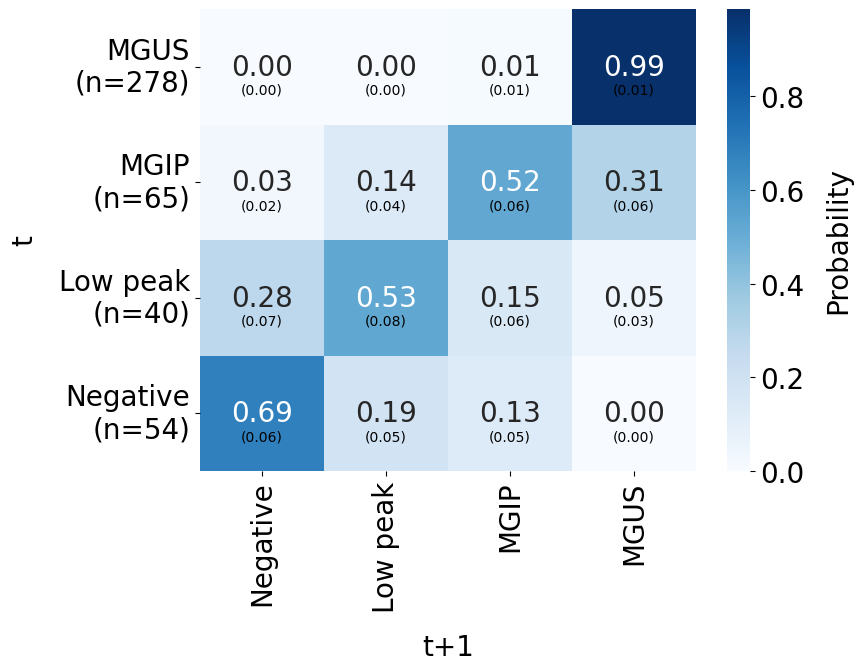

MGUS


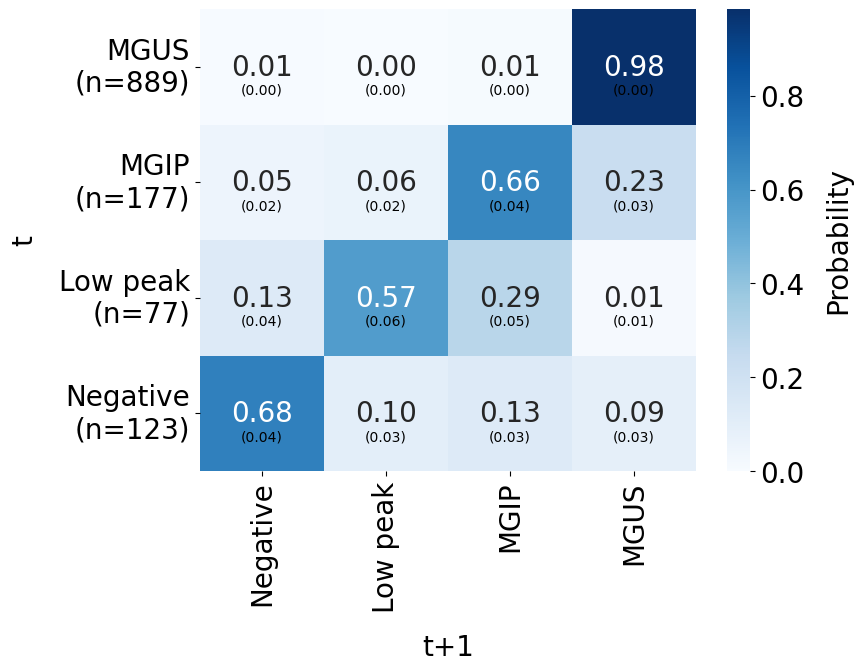

,Start,End,MM_yes,MM_total,MM_prob,MGUS_yes,MGUS_total,MGUS_prob,OddsRatio_MM_vs_MGUS,Chi2_p,Fisher_p,Recommended_test,p_value_to_use
0,Low peak,Low peak,21,40,0.525000,44,77,0.571429,NaN,0.776962,NaN,Chi-square,0.776962
1,Low peak,MGIP,6,40,0.150000,22,77,0.285714,NaN,0.160439,NaN,Chi-square,0.160439
2,Low peak,MGUS,2,40,0.050000,1,77,0.012987,4.000000,0.558601,0.268866,Fisher,0.268866
3,Low peak,Negative,11,40,0.275000,10,77,0.129870,NaN,0.091717,NaN,Chi-square,0.091717
4,MGIP,Low peak,9,65,0.138462,11,177,0.062147,NaN,0.099422,NaN,Chi-square,0.099422
5,MGIP,MGIP,34,65,0.523077,116,177,0.655367,NaN,0.083689,NaN,Chi-square,0.083689
6,MGIP,MGUS,20,65,0.307692,41,177,0.231638,NaN,0.298008,NaN,Chi-square,0.298008
7,MGIP,Negative,2,65,0.030769,9,177,0.050847,0.592593,0.751634,0.731957,Fisher,0.731957
8,MGUS,Low peak,1,278,0.003597,0,889,0.000000,inf,0.538696,0.238218,Fisher,0.238218
9,MGUS,MGIP,3,278,0.010791,9,889,0.010124,1.066667,1.000000,1.000000,Fisher,1.000000


In [6]:
import pandas as pd
import numpy as np
import os, glob, subprocess, itertools
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import chi2_contingency, fisher_exact


filt_reshaped2_indv = pd.read_csv('../data/PLCO_ms_indv.csv', sep=",")

dx = 'Mass_Spect_Diagnosis_SK_New'

filt_reshaped2_indv[dx] = filt_reshaped2_indv[dx].replace({
    "Low_MS": "Low peak",
    "MS-MGUS" : "MGUS",
    "MSL" : "Negative",
    "LC_only" : "Negative",
    "<LLMI" : "Negative",
    "C1q-C" : "Negative"
})

transitions_by_disease = {} ## comparison test

disease_dict = {'total' : 'total', 1 : 'MM', 2 : 'MGUS'}
for disease in [1, 2]:
    disease_name = disease_dict[disease]
    print(disease_name)

    df = filt_reshaped2_indv[filt_reshaped2_indv['casestat'] == disease]
    
    if disease_name == 'MGUS':
        #diagnosis_order = ['MGUS', 'MGIP', 'Low peak', 'Others', 'Negative'][::-1]
        diagnosis_order = ['MGUS', 'MGIP', 'Low peak', 'Negative'][::-1]
    elif disease_name == 'MM':
        diagnosis_order = ['MGUS', 'MGIP', 'Low peak', 'Negative'][::-1]
    
    df['Yr_before_dx_v2'] = df['Yr_before_dx'] * -1
    df = df.sort_values(by=['e_2021_1015_id', 'Yr_before_dx_v2'])
    df['Next_State'] = df.groupby('e_2021_1015_id')[dx].shift(-1)
    df['interval'] = (df['Yr_before_dx_v2'] - df.groupby('e_2021_1015_id')['Yr_before_dx_v2'].shift(-1)).abs()
    transitions = df.dropna(subset=['Next_State'])

    transition_counts = transitions.groupby([dx, 'Next_State']).size().unstack(fill_value=0)
    transition_probabilities = transition_counts.div(transition_counts.sum(axis=1), axis=0)
        
    ## save for comparison 
    transitions_by_disease[disease] = transitions.copy()
        
    ## SE 
    sample_sizes = transition_counts.sum(axis=1)
    stderr_df = np.sqrt(transition_probabilities * (1 - transition_probabilities) / sample_sizes[:, None])
    
    transition_probabilities = transition_probabilities.loc[list(reversed(diagnosis_order)), diagnosis_order]
    stderr_df = stderr_df.loc[list(reversed(diagnosis_order)), diagnosis_order]
    
    plt.figure(figsize=(8, 6))
    plt.rcParams.update({'font.size': 20})
    ax = sns.heatmap(
        transition_probabilities, 
        annot=True, 
        cmap="Blues", 
        cbar_kws={'label': 'Transition probability'},
        fmt=".2f"
    )
    colorbar = ax.collections[0].colorbar  # Get the colorbar object
    colorbar.set_label('Probability', labelpad=15)  # Set label and labelpad
    
    y_counts = transitions.groupby(dx).size().reindex(transition_probabilities.columns, fill_value=0)
    yticklabels = list(reversed([f"{label}\n(n={y_counts[label]})" for label in transition_probabilities.columns]))
    ax.set_yticklabels(yticklabels, rotation=0)

    for i in range(transition_probabilities.shape[0]):
        for j in range(transition_probabilities.shape[1]):
            prob_value = transition_probabilities.iloc[i, j]
            stderr_value = stderr_df.iloc[i, j]
            # Insert formatted error (stderr) below the value
            ax.text(
                j + 0.5,  # x position (shifted for correct placement)
                i + 0.7,  # y position (shifted for correct placement)
                f"({stderr_value:.2f})",  # Display stderr value below the probability
                ha='center', va='center', color='black', fontsize=10
            )

    plt.xlabel("t+1", labelpad=15)
    plt.ylabel("t", labelpad=15)
    plt.savefig(f'../00.Figures/PLCO_transition_probability_heatmap_{disease_name}_MSdiagnosis.pdf', bbox_inches='tight')
    plt.show()
    

# --------------------------------------------------
# Compare MM vs MGUS for each start -> end transition
# --------------------------------------------------

states_to_test = ['Negative', 'Low peak', 'MGIP', 'MGUS']
compare_results = []

trans_mm = transitions_by_disease[1].copy()
trans_mgus = transitions_by_disease[2].copy()

for start_state in states_to_test:
    mm_start = trans_mm[trans_mm[dx] == start_state].copy()
    mgus_start = trans_mgus[trans_mgus[dx] == start_state].copy()

    mm_total = len(mm_start)
    mgus_total = len(mgus_start)

    if mm_total == 0 or mgus_total == 0:
        continue

    for end_state in states_to_test:
        mm_yes = (mm_start['Next_State'] == end_state).sum()
        mm_no  = mm_total - mm_yes

        mgus_yes = (mgus_start['Next_State'] == end_state).sum()
        mgus_no  = mgus_total - mgus_yes

        table = np.array([
            [mm_yes, mm_no],
            [mgus_yes, mgus_no]
        ])

        p_chi = np.nan
        p_fisher = np.nan
        oddsratio = np.nan
        recommended = 'Chi-square'

        try:
            chi2, p_chi, dof, expected = chi2_contingency(table)

            if (expected < 5).any():
                recommended = 'Fisher'
                oddsratio, p_fisher = fisher_exact(table)
        except:
            recommended = 'Fisher'
            try:
                oddsratio, p_fisher = fisher_exact(table)
            except:
                pass

        compare_results.append({
            'Start': start_state,
            'End': end_state,
            'MM_yes': int(mm_yes),
            'MM_total': int(mm_total),
            'MM_prob': mm_yes / mm_total if mm_total > 0 else np.nan,
            'MGUS_yes': int(mgus_yes),
            'MGUS_total': int(mgus_total),
            'MGUS_prob': mgus_yes / mgus_total if mgus_total > 0 else np.nan,
            'OddsRatio_MM_vs_MGUS': oddsratio,
            'Chi2_p': p_chi,
            'Fisher_p': p_fisher,
            'Recommended_test': recommended
        })

compare_df = pd.DataFrame(compare_results)

compare_df['p_value_to_use'] = np.where(
    compare_df['Recommended_test'] == 'Fisher',
    compare_df['Fisher_p'],
    compare_df['Chi2_p']
)

compare_df = compare_df.sort_values(['Start', 'End']).reset_index(drop=True)
display(compare_df)
    
    

# 05. Visualization! MS diagnosis change over time

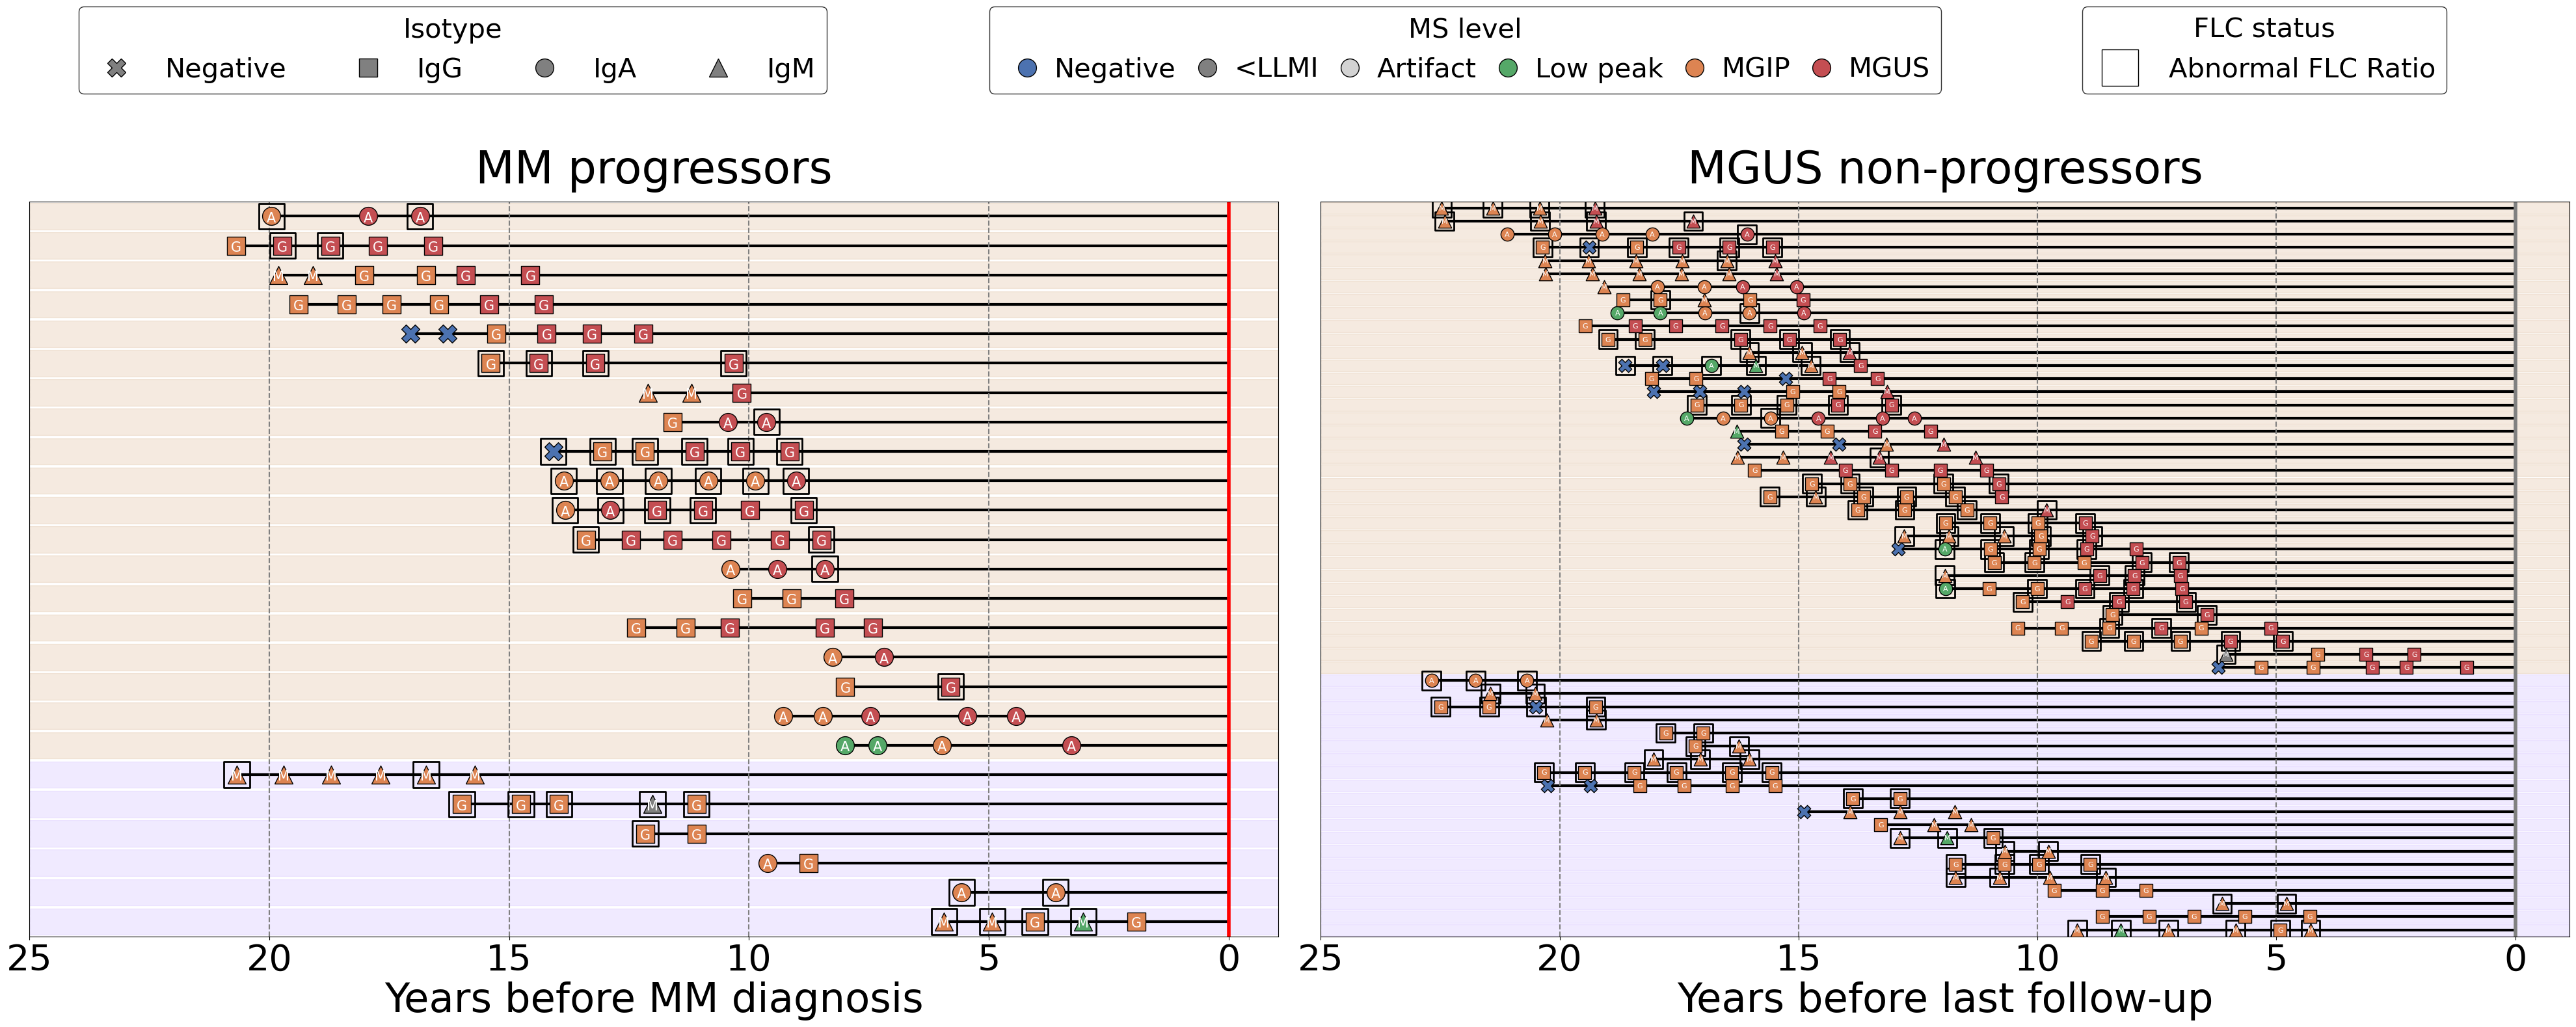

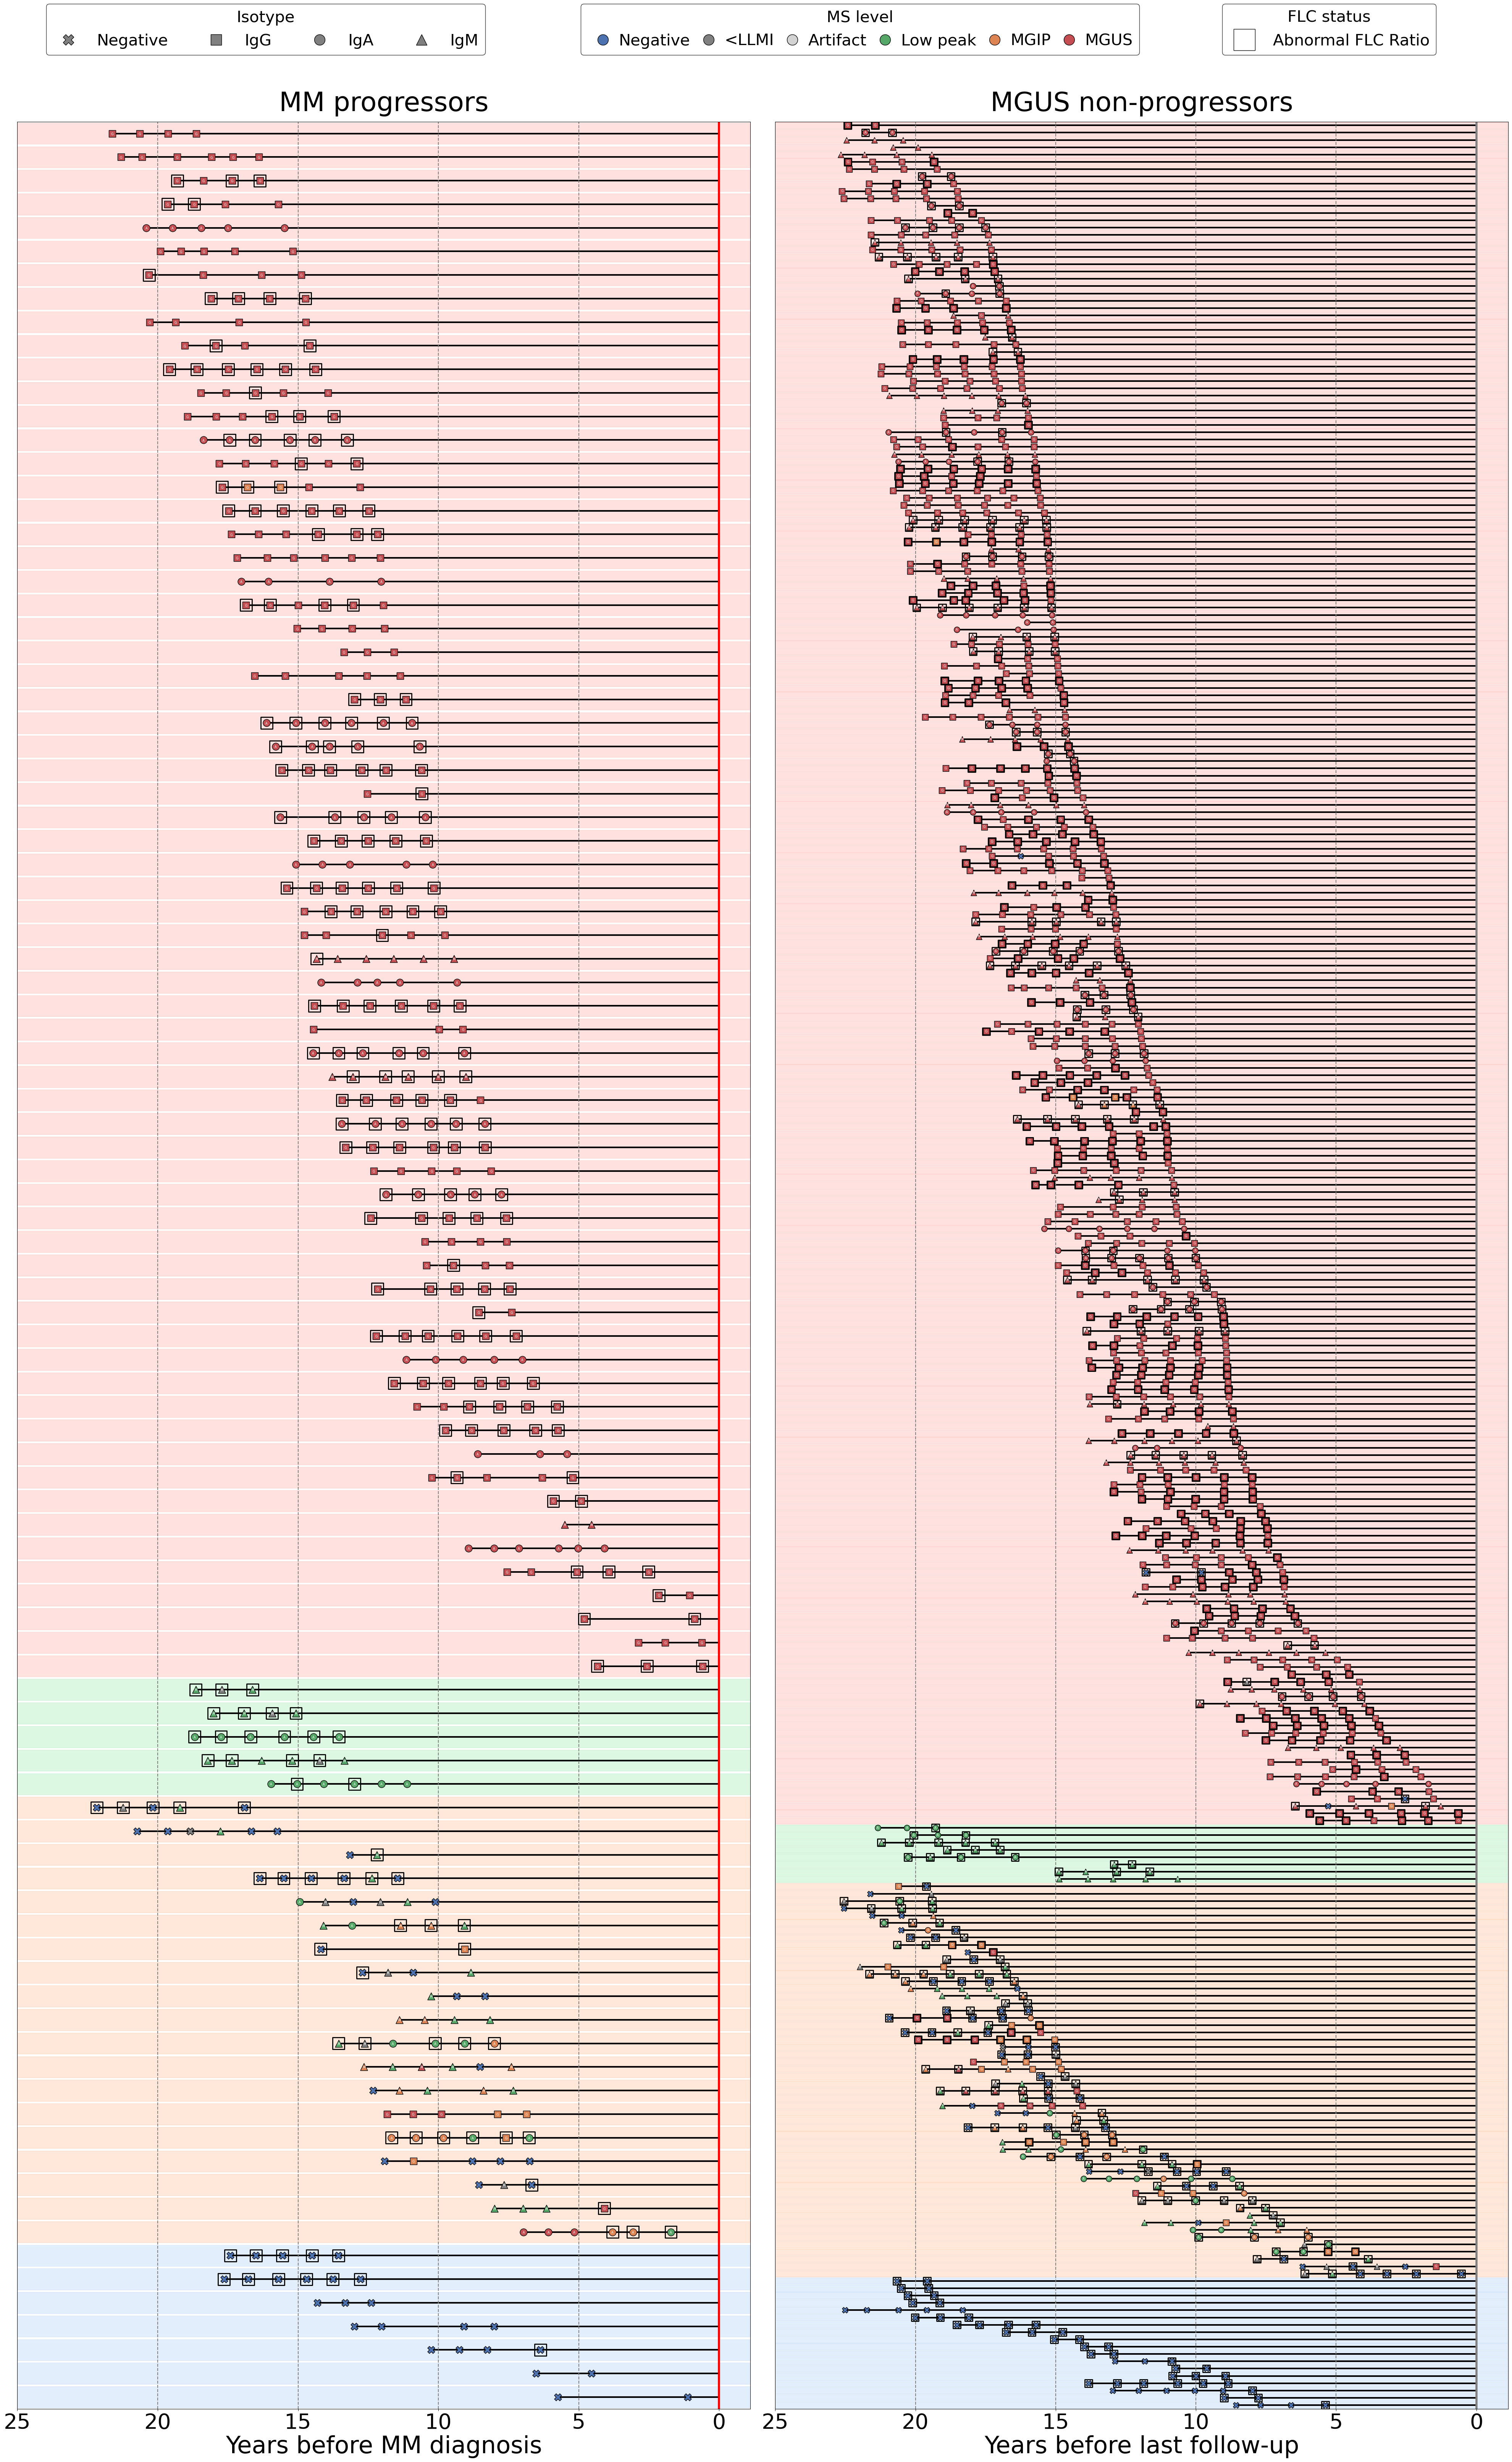

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.lines as lines
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

# Example: disease_dict
disease_dict = {1: 'MM progressors', 2: 'MGUS non-progressors', 'total': 'total'}

# Read your data
filt_reshaped2_indv = pd.read_csv('../data/PLCO_ms_indv.csv', sep=",")

replace_name_dict = {
    #'Low_MS': '<MGIP',
    'Low_MS' : 'Low peak',
    'C1q-1' : 'Artifact',
    'MS-MGUS' : 'MGUS',
}
filt_reshaped2_indv['Mass_Spect_Diagnosis_SK_New'] = filt_reshaped2_indv['Mass_Spect_Diagnosis_SK_New'].replace(replace_name_dict)

# Example color palette for diagnoses
colors = sns.color_palette("deep", n_colors=10)

# node_colors_dict = {
#     'Negative'          : colors[0],
#     '<LLMI' : 'grey',
#     #'<MGIP' : colors[2],
#     'Low peak' : colors[2],
#     'Artifact' : 'lightgrey',
#     'MGIP' : colors[1],
#     'MGUS' : colors[3],
# } #### two rows, 'Negative' is 1st row 1st column, '<LLMI' is 2nd row 1st column...

node_colors_dict = {
    'Negative'          : colors[0],
    '<LLMI' : 'grey',
    'Artifact' : 'lightgrey',
    #'<MGIP' : colors[2],
    'Low peak' : colors[2],
    'MGIP' : colors[1],
    'MGUS' : colors[3],
} 

# FLC ratio
def determine_flc_diagnosis(row):
    if not pd.isna(row['flc_ratio']):
        return 'Abnormal FLC Ratio' if row['flc_ratio'] < 0.26 or row['flc_ratio'] > 1.65 else 'Normal FLC Ratio'
    elif not pd.isna(row['FLCRatio']):
        return 'Abnormal FLC Ratio' if row['FLCRatio'] < 0.26 or row['FLCRatio'] > 1.65 else 'Normal FLC Ratio'        
    else:
        return 'NA'

filt_reshaped2_indv['FLC_diagnosis'] = filt_reshaped2_indv.apply(determine_flc_diagnosis, axis=1)

# Change 1) Type = Lambda or Kappa & Conc = 0.0 & 2) C1q-1 (artifact) --> Negative
mask_light_chain_zero = (
    filt_reshaped2_indv['Type_heavy'].isin(['Lambda', 'Kappa']) & 
    (filt_reshaped2_indv['Conc_1'] == 0.0)
)

mask_flag_condition = (filt_reshaped2_indv['Flag_1'] == 'C1q-1')

filt_reshaped2_indv.loc[mask_light_chain_zero | mask_flag_condition, 'Type_heavy'] = 'Negative'

# Key columns
SUBJ_COL = "e_2021_1015_id"
TIME_COL = "Yr_before_dx"
DX_COL   = "Mass_Spect_Diagnosis_SK_New"
CONC_COL = "Conc_1"
ISOTYPE_COL = "Type_heavy" #"Type_1"

# MGIP set
mgip_set = set(["MGIP-Low", "MGIP-High", "MGIP"])
mgus_str = "MGUS"
mgip_str = 'MGIP'
low_str = 'Low peak'

def categorize_trajectory(dx_list):
    dx_list = list(dx_list)
    # If all Negative => "Negative stable"
    if all(d == "Negative" for d in dx_list):
        return "Negative"
    # If all Negative except one --> Others
    if sum(d != "Negative" for d in dx_list) == 1:
        return "Others"

    # The earliest sample is at dx_list[-1]; the latest at dx_list[0].
    #    Find the first non-Negative going from earliest->latest:
    earliest_nonneg = None
    for diag in reversed(dx_list):  # reversed => earliest first
        if diag != "Negative":
            earliest_nonneg = diag
            break
            
    earliest_dx = dx_list[-1] # earliest diagnosis
    last_dx = dx_list[0]  # the latest diagnosis
    middle_dx = dx_list[1:-1]

    # any MGIP at any prior timepoint
    has_any_mgip = any(d in mgip_set for d in dx_list)
    
    if len(dx_list) > 2:
        # Persistent MS-MGUS
        if all(d == mgus_str for d in dx_list):
            return "Persistent MGUS"
        if earliest_nonneg == mgus_str and last_dx == mgus_str:
            return "Persistent MGUS"

        # If latest is MS-MGUS and there was any MGIP at any time -> MGIP→MS-MGUS
        if (last_dx == mgus_str) and has_any_mgip:
            return "MGIP→MGUS"

        # Persistent MGIP
        mgip_middle_allowed = all(d in {mgip_str, low_str, "Negative", '<LLMI', 'Artifiact'} for d in middle_dx)
        n_middle_low_or_neg = sum(d in {low_str, "Negative", '<LLMI', 'Artifiact'} for d in middle_dx)
        has_any_mgus = any(d == mgus_str for d in dx_list)

        if (
            earliest_nonneg == mgip_str
            and last_dx == mgip_str
            and mgip_middle_allowed
            and n_middle_low_or_neg < 2
            and not has_any_mgus
        ):
            return "Persistent MGIP"

        # Persistent Low MS
        low_middle_allowed = all(d in {low_str, "Negative", '<LLMI', 'Artifiact'} for d in middle_dx)
        n_middle_neg = sum(d in {"Negative", '<LLMI', 'Artifiact'} for d in middle_dx)
        has_any_mgip_or_mgus = any((d == mgip_str) or (d == mgus_str) for d in dx_list)

        if (
            earliest_nonneg == low_str
            and last_dx == low_str
            and low_middle_allowed
            and n_middle_neg < 2
            and not has_any_mgip_or_mgus
        ):
            return "Persistent Low peak"

        return "Others"

    else: ## only two time point
        # Persistent MS-MGUS
        if earliest_dx == mgus_str and last_dx == mgus_str:
            return "Persistent MGUS"
        
        # Persistent MGIP
        if earliest_dx == mgip_str and last_dx == mgip_str:
            return "Persistent MGIP"

        # Persistent Low MS
        if earliest_dx == low_str and last_dx == low_str:
            return "Persistent Low peak"
        
        # MGIP->MS-MGUS
        if earliest_dx == mgip_str and last_dx == mgus_str:
            return "MGIP→MGUS"
               
        return "Others"
        
pid_order_by_disease = {}     # { 'MM': [pid1, pid2, …], 'MGUS': [...] }

given_cats = ["Persistent MGIP", "MGIP→MGUS"]

cat_order = ["Negative", "Others", "Persistent Low peak", "Persistent MGUS", "Persistent MGIP", "MGIP→MGUS"]

isotype_to_marker = {'Negative': "X", 'IgG': "s", 'IgA': "o", 'IgM': "^"}
isotype_to_letter = {'Negative': "", 'IgG': "G", 'IgA': "A", 'IgM': "M"}
flc_to_marker = {'Abnormal FLC Ratio': "s", 'Normal FLC Ratio': "", 'Not Resulted': ""}

cat_colors = sns.color_palette("pastel", n_colors=len(cat_order))
category_color_map = {cat: color for cat, color in zip(cat_order, cat_colors)}

for mode in ['given', 'others']:
#for mode in ['given']:
    if mode == 'given':
        current_cats = [c for c in cat_order if c in given_cats]
        file_suffix = "given_trajectory"
        height_multiplier = 0.15  
    else:
        current_cats = [c for c in cat_order if c not in given_cats]
        file_suffix = "other_trajectory"
        height_multiplier = 0.2

    max_pids_across_diseases = []
    disease_plot_data = {}

    for disease in [1, 2]:
        disease_name = disease_dict[disease]
        data = filt_reshaped2_indv if disease == 'total' else filt_reshaped2_indv[filt_reshaped2_indv['casestat'] == disease]
        data = data.sort_values(by=[SUBJ_COL, TIME_COL], ascending=[True, True])

        grouped = data.groupby(SUBJ_COL)
        categories_dict = {}
        for pid, grp in grouped:
            dx_seq = grp[DX_COL].tolist()
            categories_dict[pid] = categorize_trajectory(dx_seq)

        data["Trajectory_Category"] = data[SUBJ_COL].map(categories_dict)

        sorted_pids = []
        for cat in current_cats:
            cat_pids = [p for p in categories_dict if categories_dict[p] == cat]
            if not cat_pids:
                continue
            cat_df = data[data[SUBJ_COL].isin(cat_pids)]
            earliest_times = cat_df.groupby(SUBJ_COL)[TIME_COL].min()
            sorted_pids.extend(earliest_times.sort_values().index.tolist())

        max_pids_across_diseases.append(len(sorted_pids))
        disease_plot_data[disease] = {
            'name': disease_name,
            'data': data[data[SUBJ_COL].isin(sorted_pids)].copy(),
            'sorted_pids': sorted_pids,
            'categories_dict': categories_dict
        }

    total_pids = max(max_pids_across_diseases)

    fig_height = max(14, total_pids * height_multiplier)
    fig, axes = plt.subplots(1, 2, figsize=(40, fig_height), sharey=False)
    plt.subplots_adjust(wspace=0.15)

    for i, disease in enumerate([1, 2]):
        ax = axes[i]
        p_info = disease_plot_data[disease]
        mode_data = p_info['data']
        sorted_pids = p_info['sorted_pids']
        categories_dict = p_info['categories_dict']
        disease_name = p_info['name']

        if not sorted_pids:
            ax.text(0.5, 0.5, "No Data", ha='center', va='center', fontsize=30)
            ax.axis('off')
            continue

        n_pids = len(sorted_pids)
        
        if mode == 'given':
        
            flc_size_norm = 800
            marker_size_norm = 400
            text_size_norm = 15
            line_offset_norm = 0.07
            if n_pids > 30:
                flc_size = max(200, flc_size_norm * (30 / n_pids))
                marker_size = max(120, marker_size_norm * (30 / n_pids))
                text_size = max(6, text_size_norm * (30 / n_pids))
                line_offset = line_offset_norm * (30 / n_pids)
            else:
                flc_size = flc_size_norm
                marker_size = marker_size_norm
                text_size = text_size_norm
                line_offset = line_offset_norm 
        else:
            flc_size_norm = 1600
            marker_size_norm = 600
            text_size_norm = 15
            line_offset_norm = 0.07
            if n_pids > 30:
                flc_size = max(200, flc_size_norm * (30 / n_pids))
                marker_size = max(120, marker_size_norm * (30 / n_pids))
                text_size = max(6, text_size_norm * (30 / n_pids))
                line_offset = line_offset_norm * (30 / n_pids)

            
        pid_to_y = {pid: idx for idx, pid in enumerate(sorted_pids)}
        mode_data[ISOTYPE_COL] = mode_data[ISOTYPE_COL].replace(np.nan, 'Negative')

        for pid, grp in mode_data.groupby(SUBJ_COL):
            y_pos = pid_to_y[pid]
            cat = categories_dict.get(pid, "Unknown")

            if cat in category_color_map:
                ax.axhspan(y_pos - 0.45, y_pos + 0.45, color=category_color_map[cat], alpha=0.3)

            xmax_val = grp[TIME_COL].max()
            ax.hlines(y=y_pos, xmin=0, xmax=xmax_val, colors="black", linestyles="-", linewidth=3)

            for idx, row in grp.iterrows():
                xval = row[TIME_COL]
                isotype = row[ISOTYPE_COL]
                flc_type = row['FLC_diagnosis']
                color = node_colors_dict.get(row[DX_COL], "grey")
                marker_shape = isotype_to_marker.get(isotype, "o")
                flc_shape = flc_to_marker.get(flc_type, "")
                isotype_letter = isotype_to_letter.get(isotype, "")

                ax.scatter(xval, y_pos, s=flc_size, facecolors='none', edgecolors='black', linewidth=2, marker=flc_shape, zorder=5)
                ax.scatter(xval, y_pos, s=marker_size, facecolors=color, edgecolors='black', marker=marker_shape, zorder=10)
                ax.text(xval, y_pos - line_offset, isotype_letter, ha='center', va='center', color='white', fontsize=text_size, zorder=11)

        if 'MM' in disease_name:
            ax.set_xlabel("Years before MM diagnosis", fontsize=45)
            ax.axvline(x=0, color="red", linestyle="-", linewidth=4)
        else:
            ax.set_xlabel("Years before last follow-up", fontsize=45)
            ax.axvline(x=0, color="grey", linestyle="-", linewidth=4)

        ax.set_title(f"{disease_name}", fontsize=50, pad=20)
        ax.set_xticks([0, 5, 10, 15, 20, 25])
        ax.set_xticklabels(["0", "5", "10", "15", "20", "25"], fontsize=40)
        ax.invert_xaxis()
        ax.set_ylim(-0.5, len(sorted_pids) - 0.5)
        ax.set_yticks([])
        ax.set_yticklabels([])

        for x in [5, 10, 15, 20, 25]:
            ax.axvline(x=x, color="grey", linestyle="--", linewidth=1.5)

    legend_elements = [
        Line2D([0], [0], marker='o', color=c, label=dx_val, markersize=20, markeredgecolor='black', linewidth=0)
        for dx_val, c in node_colors_dict.items()
    ]
    
    shape_legend_elements = [
        Line2D([0], [0], marker=shape, color="white", label=isotype, markersize=20, markeredgecolor="black", linestyle="None", markerfacecolor="grey")
        for isotype, shape in isotype_to_marker.items()
    ]

    flc_legend_elements = [
        Line2D([0], [0], marker=shape, color="white", label=flc, markersize=40, markeredgecolor="black", linestyle="None")
        for flc, shape in flc_to_marker.items() if 'Abnormal' in flc
    ]

    mm_vertical_line = lines.Line2D([0], [0], color="red", marker='|', linestyle='None', markersize=30, markeredgewidth=3, label='MM diagnosis')
    fu_vertical_line = lines.Line2D([0], [0], color="grey", marker='|', linestyle='None', markersize=30, markeredgewidth=3, label='Last follow-up')

    loc = "upper left"
    legend_x = 0.03
    
    if mode == 'given': 
        legend_y1 = 1.15
        legend_y2 = 1.045
    else:
        legend_y1 = 1.035
        legend_y2 = 1.010
    
    flc_spacing = 3.75

    fig.legend(
        handles=shape_legend_elements, title="Isotype", title_fontsize=30, columnspacing=2,
        loc=loc, bbox_to_anchor=(legend_x, legend_y1), fontsize=30, ncol=4, edgecolor='black'
    )
    
    fig.legend(
        handles=legend_elements, title="MS level", title_fontsize=30, handletextpad=0.005, columnspacing=0.15,
        loc=loc, bbox_to_anchor=(legend_x + 0.35, legend_y1), fontsize=30, ncol=6, edgecolor='black'
    )
    
    fig.legend(
        handles=flc_legend_elements, title="FLC status", title_fontsize=30, columnspacing=flc_spacing,
        loc=loc, bbox_to_anchor=(legend_x + 0.77, legend_y1), fontsize=30, ncol=4, edgecolor='black'
    )
        
#     fig.legend(
#         handles=[mm_vertical_line, fu_vertical_line], title="", title_fontsize=30, handletextpad=0.3, columnspacing=1.0,
#         loc=loc, bbox_to_anchor=(legend_x + 0.65, legend_y2), fontsize=30, ncol=2, edgecolor='black'
#     )
    
    plt.tight_layout()
    save_path = f'../00.Figures/PLCO_Combined_swimmer_{file_suffix}.pdf'
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    

In [8]:
### Compare temporal pattern between MM progressor vs MGUS non-progressor
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact

def run_chi2(group1_pos, group1_total, group2_pos, group2_total, label):
    table = [
        [group1_pos, group2_pos],
        [group1_total - group1_pos, group2_total - group2_pos]
    ]
    
    chi2, p, dof, expected = chi2_contingency(table)
    
    _, p_fisher = fisher_exact(table)
    
    print(f"=== Results for: {label} ===")
    print(f"Contingency Table:\n{pd.DataFrame(table, index=['Positive', 'Negative'], columns=['MM Progressor', 'MGUS Non-Prog'])}")
    print(f"Chi-square p-value: {p:.2e}")
    print(f"Fisher's exact p-value: {p_fisher:.2e}")
    print("-" * 30)

# 1. Persistent MS-MGUS
run_chi2(group1_pos=66, group1_total=122, group2_pos=233, group2_total=369, label="Persistent MS-MGUS")

# 2. Persistent MGIP
run_chi2(group1_pos=6, group1_total=122, group2_pos=20, group2_total=369, label="Persistent MS-MGUS")

# 3. MGIP -> MS-MGUS
run_chi2(group1_pos=19, group1_total=122, group2_pos=36, group2_total=369, label="MGIP -> MS-MGUS")
    

=== Results for: Persistent MS-MGUS ===
Contingency Table:
          MM Progressor  MGUS Non-Prog
Positive             66            233
Negative             56            136
Chi-square p-value: 9.53e-02
Fisher's exact p-value: 8.69e-02
------------------------------
=== Results for: Persistent MS-MGUS ===
Contingency Table:
          MM Progressor  MGUS Non-Prog
Positive              6             20
Negative            116            349
Chi-square p-value: 1.00e+00
Fisher's exact p-value: 1.00e+00
------------------------------
=== Results for: MGIP -> MS-MGUS ===
Contingency Table:
          MM Progressor  MGUS Non-Prog
Positive             19             36
Negative            103            333
Chi-square p-value: 1.09e-01
Fisher's exact p-value: 9.67e-02
------------------------------


# 06. Chance to have same est_mz_ratio between clones

In [9]:
import pandas as pd
import numpy as np
import itertools
from collections import Counter
from collections import defaultdict

filt_reshaped2 = pd.read_csv('../data/PLCO_ms_clone.csv', sep=",")

grouped = filt_reshaped2.groupby(['e_2021_1015_id', 'Clone_ID'])['m.z_1'].apply(set)

merged_by_redcap = defaultdict(dict)
for (redcap_id, full_aa_seq), values in grouped.items(): #full_aa_sep = Clone_ID
    merged_by_redcap[redcap_id][full_aa_seq] = values

# Function to calculate duplicate probability for groups within a redcap_id
def calculate_duplicate_probability(grouped_dict, threshold=3):
    # Flatten the group-value structure
    group_values = [(group, value) for group, values in grouped_dict.items() for value in values]
    
    # Initialize variables to count the total number of comparisons and the shared count
    total_comparisons = 0
    shared_count = 0
    
    # Compare each pair of m/z values from different groups
    for i, (group, value) in enumerate(group_values):
        for j, (other_group, other_value) in enumerate(group_values):
            if i < j:  # Avoid comparing the same pair twice
                total_comparisons += 1
                if group != other_group and abs(value - other_value) < threshold:
                    shared_count += 1
    
    # Calculate the probability
    return shared_count / total_comparisons if total_comparisons > 0 else 0


# Apply the function to each redcap_id
results = []
for redcap_id, groups in merged_by_redcap.items():
    probability = calculate_duplicate_probability(groups)
    print(f"redcap_id: {redcap_id}, probability: {probability:.2f}")
    results.append(probability)

# Calculate the average probability
average_probability = np.mean(results)
print(f"average probability: {average_probability:.2e}")

redcap_id: MGUS-001, probability: 0.00
redcap_id: MGUS-002, probability: 0.00
redcap_id: MGUS-003, probability: 0.00
redcap_id: MGUS-004, probability: 0.00
redcap_id: MGUS-005, probability: 0.00
redcap_id: MGUS-006, probability: 0.00
redcap_id: MGUS-007, probability: 0.00
redcap_id: MGUS-008, probability: 0.00
redcap_id: MGUS-009, probability: 0.00
redcap_id: MGUS-010, probability: 0.00
redcap_id: MGUS-011, probability: 0.00
redcap_id: MGUS-012, probability: 0.00
redcap_id: MGUS-013, probability: 0.00
redcap_id: MGUS-014, probability: 0.00
redcap_id: MGUS-015, probability: 0.00
redcap_id: MGUS-016, probability: 0.00
redcap_id: MGUS-017, probability: 0.00
redcap_id: MGUS-018, probability: 0.00
redcap_id: MGUS-019, probability: 0.00
redcap_id: MGUS-020, probability: 0.00
redcap_id: MGUS-022, probability: 0.00
redcap_id: MGUS-023, probability: 0.00
redcap_id: MGUS-024, probability: 0.00
redcap_id: MGUS-025, probability: 0.00
redcap_id: MGUS-026, probability: 0.00
redcap_id: MGUS-027, prob

# 07. Clonal Dynamic Pattern

In [10]:
import pandas as pd
import numpy as np
import os, glob, subprocess, itertools
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

filt_reshaped2_indv = pd.read_csv('../data/PLCO_ms_indv.csv', sep=",")

subj_col = "e_2021_1015_id"
clone_col = "Clone_ID"
time_col = "Yr_before_dx"
diag_col = 'Mass_Spect_Diagnosis_SK_New'

### Others
filt_reshaped2_indv[diag_col] = filt_reshaped2_indv[diag_col].replace({
    "Low_MS":"Low MS",
    "MSL" : "Negative",
    "LC_only" : "Negative",
    "<LLMI" : "Negative",
    "C1q-C" : "Negative"
})

def detect_clone_shift(data, clone_col=clone_col, subject_col=subj_col, time_col=time_col):
    clone_shift_dict = {}

    for pid, grp in data.groupby(subject_col):
        # Sort by time in descending order (latest sample first)
        grp = grp.sort_values(by=time_col, ascending=False)

        # Get the number of unique Clone_IDs for this person
        unique_clones = grp[clone_col].nunique()

        # If more than one unique Clone_ID exists, it means a shift occurred
        has_shift = unique_clones > 1

        clone_shift_dict[pid] = has_shift
    
    return clone_shift_dict

def classify_group(group):
    # Extract only real values excluding NaN
    vals = group['clonality_group2'].dropna()
    dxs = group[diag_col].dropna()

    if vals.empty:
        if (dxs == 'Negative').all():
            return 'Negative'
        else: 
            return 'Single'
            
    if len(vals) == 1:
        return 'Transient'

    if (vals == 'Single').all():
        return 'Single'

    return 'Multiple'

disease_labels = {1: "MM patients", 2: "MGUS non-progressor"}
disease_counts = {}
for disease in [1, 2]:
#for disease in [1]:
    disease_name = disease_labels[disease]
    print(f"**************************** {disease_name} ****************************")
    
    # Subset data based on disease status
    data = filt_reshaped2_indv if disease == 'total' else filt_reshaped2_indv[filt_reshaped2_indv['casestat'] == disease]
    
    total_number = len(data.groupby(subj_col))
    
    ### remove 'Others' (c1q-c, <llmi, msl)
    data = data[data['Conc_1'] != 0]
    data = data[data['Conc_1'].notna()]
    data = data[~data['Flag_1'].isin(['<LLMI', 'MSL', 'C1q-C'])]

    ### remove kappa lambda
    data = data[~data['Type_1'].isin(['Kappa', 'Lambda'])]
    
    # Apply category
    label_by_pid = (
        data
        .groupby(subj_col)
        .apply(classify_group)
        .rename('Clonality_Category')
    )
 
    data = data.merge(label_by_pid, left_on=subj_col, right_index=True)

    # 1. Count per category
    category_counts = label_by_pid.value_counts()

    # 2. Fraction (ratio)
    category_fraction = label_by_pid.value_counts(normalize=True) * 100

    print("=== Category Counts ===")
    print(category_counts)
    
    ########## Use Multiple ##########

    multiple_data = data[data['Clonality_Category'] == 'Multiple']
    
    # Run detection
    clone_shifts = detect_clone_shift(multiple_data)

    clone_shifts_true = {pid: shift for pid, shift in clone_shifts.items() if shift}

    for pid, shift in clone_shifts_true.items():
        print(pid, multiple_data[multiple_data[subj_col] == pid][diag_col].tolist())

    # Count individuals with & without clone shifts
    shift_counts = pd.Series(clone_shifts).value_counts()
    
    # Store counts for plotting
    disease_counts[disease] = {
        "Subclonal: Clonal Dominance": shift_counts.get(False, 0),
        "Subclonal: Shifted Dominance": shift_counts.get(True, 0)
    }
    
    # Get median years (1st timepoint) of each groups
    time_stats = {}

    # Step 1: Get individual groups
    classical_ids = list(set(data[data['Clonality_Category'] == 'Single'][subj_col].tolist()))
    clonal_dom_ids = [pid for pid, shift in clone_shifts.items() if not shift]
    shifted_dom_ids = [pid for pid, shift in clone_shifts.items() if shift]

    # Step 2: Define a function to get first timepoint per individual
    def get_first_timepoints(data, id_list):
        first_times = []
        for pid in id_list:
            person_data = data[data[subj_col] == pid]
            if not person_data.empty:
                first_time = person_data[time_col].max()  # Largest value = earliest in time
                first_times.append(first_time)
        return first_times

    # Step 3: Compute for each group
    time_stats["Monoclonal persistence"] = get_first_timepoints(data, classical_ids)
    time_stats["Single dominance"] = get_first_timepoints(multiple_data, clonal_dom_ids)
    time_stats["Shifting Dominance"] = get_first_timepoints(multiple_data, shifted_dom_ids)


    pos_number = len(data[data['Clonality_Category'].isin(['Multiple', 'Single'])].groupby(subj_col))
    print(f"Total number: {total_number}, Total MS positive (>=2): {pos_number}")
    
    # Step 4: Print stats
    for group, times in time_stats.items():
        if times:
            median_val = np.median(times)
            min_val = np.min(times)
            max_val = np.max(times)
        else:
            print(f"{group}: No data available.")
    
        print(f"******** {group}: n={len(times)} ({len(times)/pos_number*100:.0f}%)" )
        print(f"Median yr before dx: {median_val:.1f} ({min_val:.1f}-{max_val:.1f})")
        
        
    ############################ Isotype change
    # Group by patient and get first/last non-negative timepoints
    results = []
    for pid, group in data.groupby('e_2021_1015_id'):
        group = group.sort_values(by='Yr_before_dx', ascending=False)  # earliest first

        # Get earliest and latest timepoints
        first = group.iloc[0]
        last = group.iloc[-1]

        # Store results
        results.append({
            'id': pid,
            'first_Type_heavy': first['Type_heavy'],
            'last_Type_heavy': last['Type_heavy'],
            'first_Yr_before_dx': first['Yr_before_dx'],
            'last_Yr_before_dx': last['Yr_before_dx']
        })

    # Convert to DataFrame
    shift_df = pd.DataFrame(results)

    # Step 3: Count cases where first is IgM
    igm_cases = shift_df[shift_df['first_Type_heavy'] == 'IgM']
    igm_total = len(igm_cases)

    # Step 4: Of those, count how many shifted to IgG or IgA
    total = len(results)
    igm_switched = igm_cases[igm_cases['last_Type_heavy'].isin(['IgG', 'IgA'])]
    igm_switched_igg = igm_cases[igm_cases['last_Type_heavy'].isin(['IgG'])]
    igm_switched_igg_count = len(igm_switched_igg)
    igm_switched_iga = igm_cases[igm_cases['last_Type_heavy'].isin(['IgA'])]
    igm_switched_iga_count = len(igm_switched_iga)
    
    
    igm_switched_id = igm_switched['id'].tolist()

    print("**************** Isotype change (IgM->IgG/A) ")
    print(f"Total individuals with initial IgM: {igm_total}, {igm_total/pos_number*100:.0f}%")
    print(f"Of those, number that switched to IgG: {igm_switched_igg_count}, {igm_switched_igg_count/igm_total*100:.0f}%")
    print(f"Of those, number that switched to IgA: {igm_switched_iga_count}, {igm_switched_iga_count/igm_total*100:.0f}%")
    print(igm_cases['id'].tolist())
    print(igm_switched_id)

    
      

**************************** MM patients ****************************
=== Category Counts ===
Multiple     87
Single       11
Transient     9
Name: Clonality_Category, dtype: int64
MM-015 ['MS-MGUS', 'MS-MGUS', 'MGIP']
MM-020 ['MGIP', 'MGIP']
MM-021 ['MS-MGUS', 'MS-MGUS', 'MS-MGUS', 'MS-MGUS', 'MS-MGUS', 'MS-MGUS']
MM-026 ['Low MS', 'MGIP', 'Low MS', 'MGIP', 'MGIP', 'MGIP']
MM-031 ['Low MS', 'Low MS', 'Low MS', 'Low MS', 'Low MS']
MM-041 ['MS-MGUS', 'MS-MGUS', 'MS-MGUS', 'MS-MGUS', 'MGIP']
MM-050 ['Low MS', 'Low MS']
MM-061 ['MS-MGUS', 'MS-MGUS', 'MGIP', 'MGIP', 'MGIP', 'MGIP']
MM-080 ['Low MS', 'MGIP', 'MGIP', 'Low MS', 'Low MS']
MM-083 ['Low MS', 'Low MS', 'Low MS', 'Low MS', 'Low MS', 'Low MS']
MM-096 ['MS-MGUS', 'MS-MGUS', 'MGIP', 'MGIP']
MM-099 ['MGIP', 'Low MS', 'Low MS', 'Low MS', 'Low MS']
MM-100 ['MGIP', 'Low MS', 'MGIP', 'MGIP', 'MGIP']
MM-106 ['MS-MGUS', 'MS-MGUS', 'MS-MGUS', 'MS-MGUS', 'MS-MGUS', 'MGIP']
MM-120 ['MS-MGUS', 'MGIP', 'MGIP']
MM-124 ['MGIP', 'Low MS', 'MS-MGUS'

# 08. Visualize all clones + MGIP->MGUS clones

[MM] MGIP->MS-MGUS | patient=MM-015 | clone=E-032997-1Clone_1 | isotype=IgG
[MM] MGIP->MS-MGUS | patient=MM-015 | clone=E-032997-1Clone_3 | isotype=IgA
[MM] MGIP->MS-MGUS | patient=MM-016 | clone=E-066387-4Clone_1 | isotype=IgG
[MM] MGIP->MS-MGUS | patient=MM-023 | clone=F-143995-1Clone_2 | isotype=IgA
[MM] MGIP->MS-MGUS | patient=MM-024 | clone=F-157972-3Clone_1 | isotype=IgG
[MM] MGIP->MS-MGUS | patient=MM-027 | clone=H-049677-0Clone_1 | isotype=IgA
[MM] MGIP->MS-MGUS | patient=MM-029 | clone=I-087748-3Clone_1 | isotype=IgG
[MM] MGIP->MS-MGUS | patient=MM-038 | clone=N-004423-0Clone_1 | isotype=IgA
[MM] MGIP->MS-MGUS | patient=MM-045 | clone=P-009501-9Clone_1 | isotype=IgG
[MM] MGIP->MS-MGUS | patient=MM-058 | clone=Q-017017-6Clone_1 | isotype=IgG
[MM] MGIP->MS-MGUS | patient=MM-061 | clone=R-016550-7Clone_5 | isotype=IgG
[MM] MGIP->MS-MGUS | patient=MM-065 | clone=R-121148-2Clone_1 | isotype=IgG
[MM] MGIP->MS-MGUS | patient=MM-066 | clone=R-125090-1Clone_1 | isotype=IgA
[MM] MGIP->M

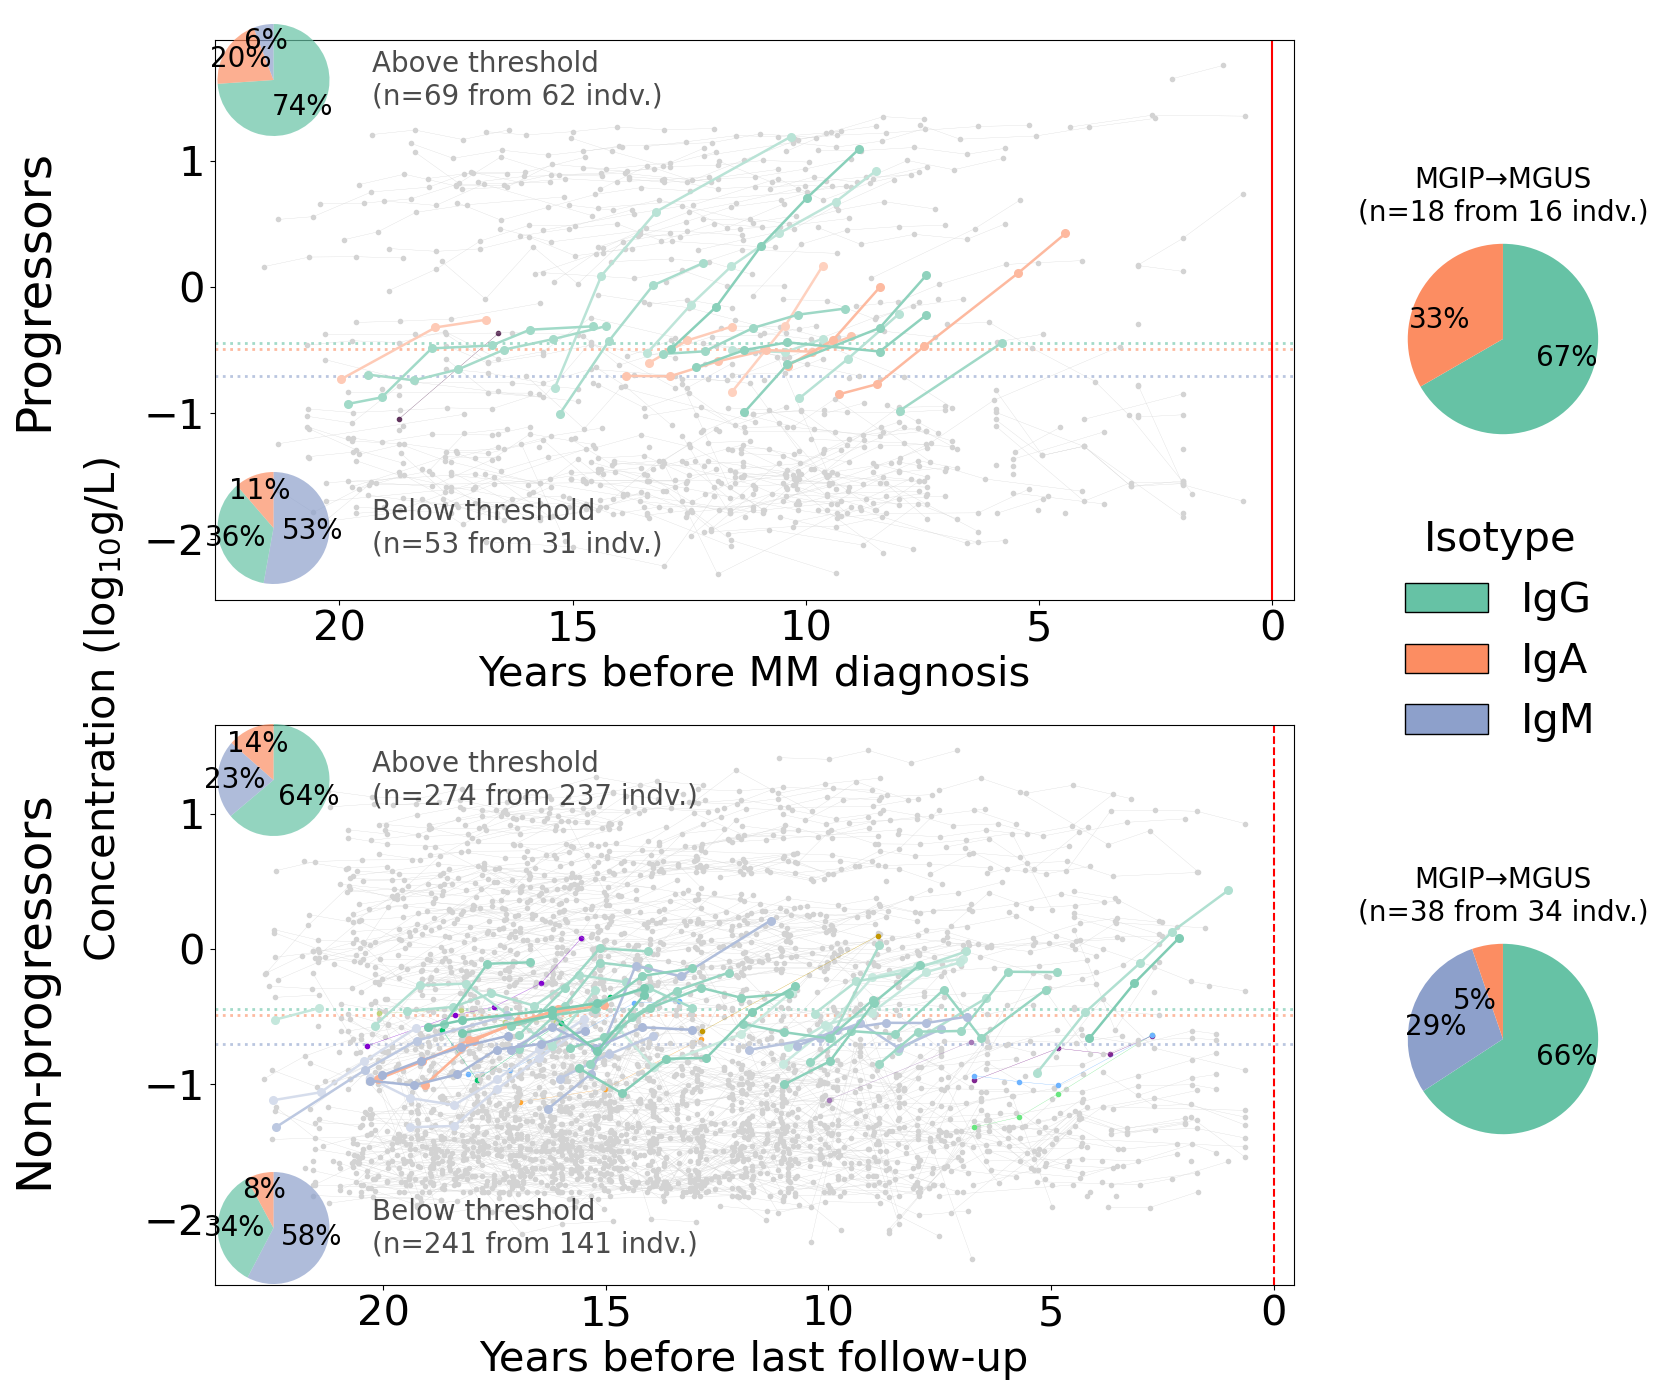

In [11]:
import colorcet as cc
import matplotlib
matplotlib.colormaps._allow_override_builtin = True  
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from matplotlib.lines import Line2D
from matplotlib.text import Text
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import mannwhitneyu
from statannotations.Annotator import Annotator
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from collections import defaultdict
import matplotlib.colors as mcolors
import colorsys

def lighten_color(color, amount=0.5):
    """
    ligher if amount is larger (0-1)
    """
    try:
        c = mcolors.cnames[color]
    except Exception:
        c = color
    r, g, b = mcolors.to_rgb(c)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = 1 - amount * (1 - l)
    r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)
    return (r2, g2, b2)

def get_log_thresh(val):
    if pd.isna(val) or val <= 0:
        return -np.inf
    return np.log10(val)

def generate_palette_from_base(base_color, n):
    """
    n * shade per same hue based on base_color
    """
    if n <= 1:
        return [base_color]

    shades = []
    amounts = np.linspace(0.35, 0.9, n)
    for a in amounts:
        shades.append(lighten_color(base_color, amount=a))
    return shades


def build_clone_color_maps(df):
    igh_colors = {
        'IgG': '#66c2a5',
        'IgA': '#fc8d62',
        'IgM': '#8da0cb',
    }

    clone_ids = sorted(df['Clone_ID'].dropna().unique())
    isotype_counts = defaultdict(int)
    clone_id_to_label = {}

    for clone_id in clone_ids:
        clone_data = df[df['Clone_ID'] == clone_id]
        unique_types = clone_data['Type_heavy'].dropna().unique()

        if len(unique_types) == 0:
            label = f"Unknown {clone_id}"
        else:
            label = str(unique_types[0])

        clone_id_to_label[clone_id] = label
        iso = label.split()[0]
        isotype_counts[iso] += 1

    isotype_shades = {
        iso: generate_palette_from_base(base_color, isotype_counts[iso])
        for iso, base_color in igh_colors.items()
        if isotype_counts[iso] > 0
    }

    shade_indices = defaultdict(int)
    clone_id_to_color = {}

    for clone_id in clone_ids:
        label = clone_id_to_label[clone_id]
        iso = label.split()[0]

        if iso in isotype_shades:
            idx = shade_indices[iso]
            clone_id_to_color[clone_id] = isotype_shades[iso][idx]
            shade_indices[iso] += 1
        else:
            clone_id_to_color[clone_id] = "#999999"

    return clone_ids, clone_id_to_label, clone_id_to_color



filt_reshaped2 = pd.read_csv('../data/PLCO_ms_clone.csv', sep=",")

filt_reshaped2 = filt_reshaped2.dropna(subset=['Conc_1'])

filt_reshaped2['Conc_log10'] = np.log10(filt_reshaped2['Conc_1'])

filt_reshaped2.replace([np.inf, -np.inf], np.nan, inplace=True)

filt_reshaped2 = filt_reshaped2.dropna(subset=['Conc_log10'])

disease_dict = {'total' : 'total', 1 : 'MM', 2 : 'MGUS'}

fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(2, 2, width_ratios=[3, 1])

all_condition_summary = {}
transition_ybdx_all = {}

traj_font=30
pie_font=20

igh_colors = {
    'IgG': '#66c2a5',  
    'IgA': '#fc8d62',  
    'IgM': '#8da0cb',  
}

bs_thresh_map = {
    'IgG': 0.359,
    'IgA': 0.325,
    'IgM': 0.197,
}

mgip_thresh_map = {
    'IgG': 0.000,   # include all IgG
    'IgA': 0.070,
    'IgM': 0.044,
}


#color_palette = sns.color_palette("husl", 100)
color_palette = cc.glasbey[:100]
color_index = 0

for i, disease in enumerate([1, 2]):
    disease_name = disease_dict[disease]
    subset = filt_reshaped2[filt_reshaped2['casestat'] == disease]
    ax_main = fig.add_subplot(gs[i, 0])
    condition_summary = {"Stable MS-MGUS": [], "Stable MGIP": [], "MGIP->MS-MGUS": [], "Others": []}
    transition_ybdx = []
    transition_line_info = []
    
    clone_ids_all, clone_id_to_label, clone_id_to_color = build_clone_color_maps(filt_reshaped2)
    
    mgip_progressor_clones = []
    
    baseline_mgip_clones = 0

    for idx, (group_key, group) in enumerate(subset.groupby(['e_2021_1015_id', 'Clone_ID'])):
        patient_id, clone_id = group_key
        x, y = 'Yr_before_dx', 'Conc_log10'

        isotype = group['Type_heavy'].dropna().iloc[0]

        if isotype not in bs_thresh_map or isotype not in mgip_thresh_map:
            condition_summary["Others"].append(group_key)
            continue

        bs_thresh = np.log10(bs_thresh_map[isotype])
        mgip_thresh = np.log10(mgip_thresh_map[isotype]) if mgip_thresh_map[isotype] > 0 else -np.inf

        yvals = group[y]

        all_above_bs = (yvals >= bs_thresh).all()

        all_in_mgip_range = ((yvals >= mgip_thresh) & (yvals < bs_thresh)).all()

        ### FIRST MGIP & ANY CROSS BS
        #first_in_mgip_range = (yvals.iloc[0] >= mgip_thresh) and (yvals.iloc[0] < bs_thresh)
        #ever_crossed_bs = (yvals >= bs_thresh).any()  

        ### ANY MGIP & LAST CROSS BS 
        #pre_last = yvals.iloc[:-1]
        #any_in_mgip_range = ((pre_last >= mgip_thresh) & (pre_last < bs_thresh)).any()        
        
        ## BASELINE MGIP & LAST CROSS BS (MAKE SURE CLONE IS MS-MGUS AT LAST SAMPLE)
        baseline_mgip = (yvals.iloc[0] >= mgip_thresh) & (yvals.iloc[0] < bs_thresh)
        if baseline_mgip:
            baseline_mgip_clones += 1
        last_above_bs = yvals.iloc[-1] >= bs_thresh
        
        color = color_palette[color_index % len(color_palette)]
        color_index += 1

        if all_above_bs:
            condition = "Stable MS-MGUS"
            color = "lightgrey"
            linewidth, markersize = 0.2, 3
        elif all_in_mgip_range:
            condition = "Stable MGIP"
            color = "lightgrey"
            linewidth, markersize = 0.2, 3
        #elif first_in_mgip_range and ever_crossed_bs:
        elif baseline_mgip and last_above_bs:
            # Extract and sort timepoints
            timepoints = group['timepoint'].unique()
            timepoint_nums = sorted([int(re.search(r'\d+', t).group()) for t in timepoints])

            # Check for discontinuity
            is_continuous = all(timepoint_nums[i] + 1 == timepoint_nums[i + 1] for i in range(len(timepoint_nums) - 1))

            if is_continuous:
                condition = "MGIP->MS-MGUS"
                isotype = group['Type_heavy'].dropna().iloc[0]   # Unify instead of Type_1
                color = clone_id_to_color.get(clone_id, igh_colors.get(isotype, 'grey'))
                linewidth, markersize = 1.8, 5.5
                                
                y_vals = group[y].values
                ybdx_vals = group['Yr_before_dx'].values
                for i in range(len(y_vals) - 1):
                    if y_vals[i] < bs_thresh and y_vals[i+1] >= bs_thresh:
                        transition_ybdx.append(ybdx_vals[i])
                        transition_line_info.append((ybdx_vals[i], isotype))
                        break 
                print(
                    f"[{disease_name}] MGIP->MS-MGUS | patient={patient_id} | clone={clone_id} | isotype={isotype}"
                )
                mgip_progressor_clones.append(clone_id)
                    
        else:
            condition = "Others"
            color = "lightgrey"
            linewidth, markersize = 0.2, 3

        zorder_value = 5 if condition == "MGIP->MS-MGUS" else 1

        condition_summary[condition].append({
            'patient_id': patient_id,
            'clone_id': clone_id,
            'isotype_heavy': isotype
        })

        ax_main.plot(group[x], group[y],
                     color=color, lw=linewidth,
                     marker='o', markersize=markersize,
                     zorder=zorder_value)
    
    print(f"How many MGIP->MGUS clones: N = {len(mgip_progressor_clones)} out of total baseline MGIP M-protein = {baseline_mgip_clones} ({len(mgip_progressor_clones)/baseline_mgip_clones*100:.0f}%)")
    print(mgip_progressor_clones)
    
    
    for iso in ['IgG', 'IgA', 'IgM']:
        bs_log = get_log_thresh(bs_thresh_map[iso])
        ax_main.axhline(
            y=bs_log,
            color=igh_colors[iso],
            linestyle=':',
            lw=2,
            alpha=0.6,
            zorder=0
        )
    
    ax_main.axvline(x=0, color='red', linestyle='-' if disease_name == 'MM' else '--', label='timpoint dx')
    ax_main.invert_xaxis()
    if disease_name == "MM":
        disease_title = 'Progressed to MM'
        ax_main.set_xlabel("Years before MM diagnosis", fontsize=traj_font)
    else:
        disease_title = 'MGUS non-progressor'
        ax_main.set_xlabel("Years before last follow-up", fontsize=traj_font)
    ax_main.tick_params(axis='both', labelsize=traj_font)  

    # PIE CHART coordinate
    if disease_name == "MM":
        base_y = 0.90
    else:
        base_y = 0.40

    cond_name_dict = {'Stable MS-MGUS' : 'Above threshold',
             'MGIP->MS-MGUS' : 'MGIP->MS-MGUS',
             'Stable MGIP' : 'Below threshold'}
        
    for j, cond in enumerate(['Stable MS-MGUS', 'Stable MGIP']):
        df_cond = pd.DataFrame(condition_summary[cond])
        if not df_cond.empty:
            iso_counts = df_cond['isotype_heavy'].value_counts()
            labels = iso_counts.index.tolist()
            sizes = iso_counts.values.tolist()
            colors = [igh_colors.get(label, 'grey') for label in labels]
            n_clones = df_cond['clone_id'].nunique()
            n_patients = df_cond['patient_id'].nunique()

            pie_width = 0.10  
            pie_height = 0.10
            pos_x = 0.05
            pos_y = base_y - j * 0.32

            ax_pie = fig.add_axes([pos_x, pos_y, pie_width, pie_height])
            wedges, texts = ax_pie.pie(
                sizes,
                labels=None,
                colors=colors,
                startangle=90,
                counterclock=False,
                textprops={'fontsize': pie_font},
                wedgeprops={'alpha': 0.7}  
            )

            # add percent labels manually (optional)
            for w, s in zip(wedges, sizes):
                ang = (w.theta2 + w.theta1) / 2
                x = 0.7 * np.cos(np.deg2rad(ang))
                y = 0.7 * np.sin(np.deg2rad(ang))
                ax_pie.text(x, y, f"{s / sum(sizes) * 100:.0f}%", ha='center', va='center', fontsize=pie_font)

            ax_pie.text(1.2, 0.5,
                        f"{cond_name_dict[cond]}\n(n={n_clones} from {n_patients} indv.)",
                        transform=ax_pie.transAxes,
                        fontsize=pie_font,  alpha=0.7,
                        va='center', ha='left')

    # MGIP->MS-MGUS Pie Chart
    df_mid = pd.DataFrame(condition_summary['MGIP->MS-MGUS'])
    if not df_mid.empty:
        iso_counts = df_mid['isotype_heavy'].value_counts()
        labels = iso_counts.index.tolist()
        sizes = iso_counts.values.tolist()
        colors = [igh_colors.get(label, 'grey') for label in labels]
        n_clones = df_mid['clone_id'].nunique()
        n_patients = df_mid['patient_id'].nunique()

        # get ax_main's position and calculate center Y
        plt.draw()
        main_pos = ax_main.get_position()
        pie_width = 0.17
        pie_height = 0.17

        if disease_name == 'MM':
            center_y = main_pos.y0 + (main_pos.height / 2) + 0.06
        elif disease_name == 'MGUS':
            center_y = main_pos.y0 + (main_pos.height / 2) - 0.02
        left_x = main_pos.x1 + 0.13  # a bit to the right of ax_main

        ax_pie_mid = fig.add_axes([left_x, center_y - pie_height / 2, pie_width, pie_height])
    
        ax_pie_mid.pie(
            sizes,
            labels=[f'{size / sum(sizes) * 100:.0f}%' for label, size in zip(labels, sizes)],
            colors=colors,
            startangle=90,
            counterclock=False,
            labeldistance = 0.4,
            textprops={'fontsize': pie_font}
        )
        ax_pie_mid.text(0.5, 1.1,
                        f"MGIP→MGUS\n(n={n_clones} from {n_patients} indv.)",
                        transform=ax_pie_mid.transAxes,
                        fontsize=pie_font,
                        va='center', ha='center')

    all_condition_summary[disease_name] = condition_summary
    transition_ybdx_all[disease_name] = transition_ybdx

# Y-axis
fig.text(-0.02, 0.5, 'Concentration (log$_{10}$g/L)', fontsize=traj_font, va='center', 
         rotation='vertical')
## Group
bbox_style = dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4', 
                  linewidth=1.2)

fig.text(-0.05, 0.80, 'Progressors',
         fontsize=traj_font+5, va='center', ha='center',
         rotation='vertical')# , bbox=bbox_style)

fig.text(-0.05, 0.30, 'Non-progressors',
         fontsize=traj_font+5, va='center', ha='center',
         rotation='vertical') #, bbox=bbox_style)

# Isotype legend
legend_elements = [
    Patch(facecolor=igh_colors['IgG'], edgecolor='black', label='IgG'),
    Patch(facecolor=igh_colors['IgA'], edgecolor='black', label='IgA'),
    Patch(facecolor=igh_colors['IgM'], edgecolor='black', label='IgM'),
]

fig.legend(
    handles=legend_elements,
    title="Isotype",
    title_fontsize=traj_font,
    fontsize=traj_font,
    loc='lower right',
    bbox_to_anchor=(0.95, 0.45), 
    frameon=False
)

plt.tight_layout()
plt.savefig("../00.Figures/PLCO_clone_MGIP_progressor_clones.pdf", bbox_inches='tight')
plt.show()




In [12]:
### Stat test for IgM Clone fraction between Progressors and Non-progressors
# MM progressor
mm_IgM = 0     
mm_total = 18  # number of MGIP->MGUS (clone)

# MGUS non-progressor
mgus_IgM = round(38*0.29)  
mgus_total = 38 - mgus_IgM

from scipy.stats import fisher_exact

# 2x2 contingency table
table = [[mm_IgM, mm_total - mm_IgM],
         [mgus_IgM, mgus_total - mgus_IgM]]

oddsratio, pval = fisher_exact(table)
print(f"p = {pval:.3e}")

p = 1.404e-03


In [13]:
### Stat test for MGIP->MGUS clone fraction out of total baseline MGIP between Progressors and Non-progressors
# MM progressor
mm_mgip_inc = 18     
mm_mgip_total = 92  

# MGUS non-progressor
mgus_mgip_inc = 38
mgus_mgip_total = 352

from scipy.stats import fisher_exact

# 2x2 contingency table
table = [[mm_mgip_inc, mm_mgip_total - mm_mgip_inc],
         [mgus_mgip_inc, mgus_mgip_total - mgus_mgip_inc]]

oddsratio, pval = fisher_exact(table)
print(f"p = {pval:.3e}")

p = 3.321e-02


# 09. Individual dynamic plot

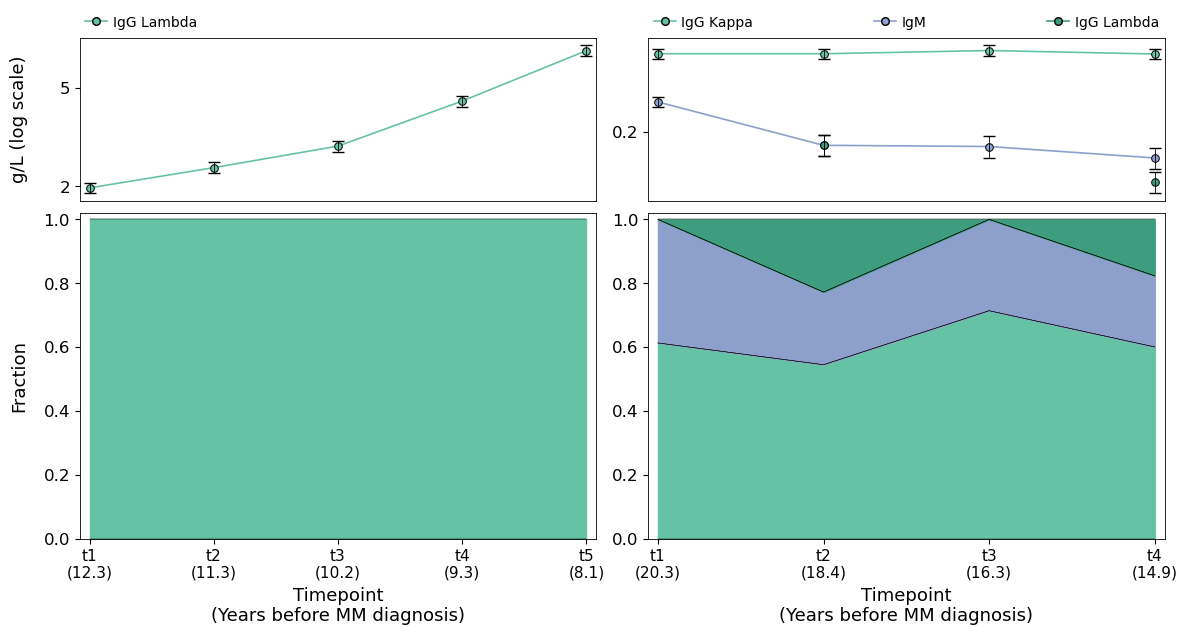

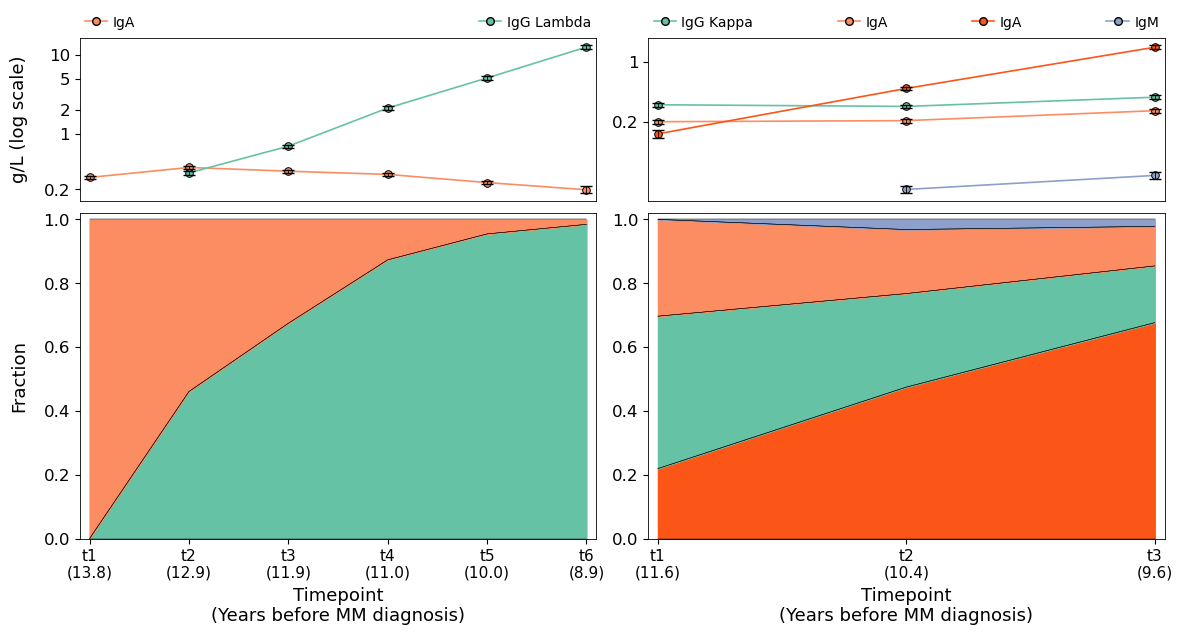

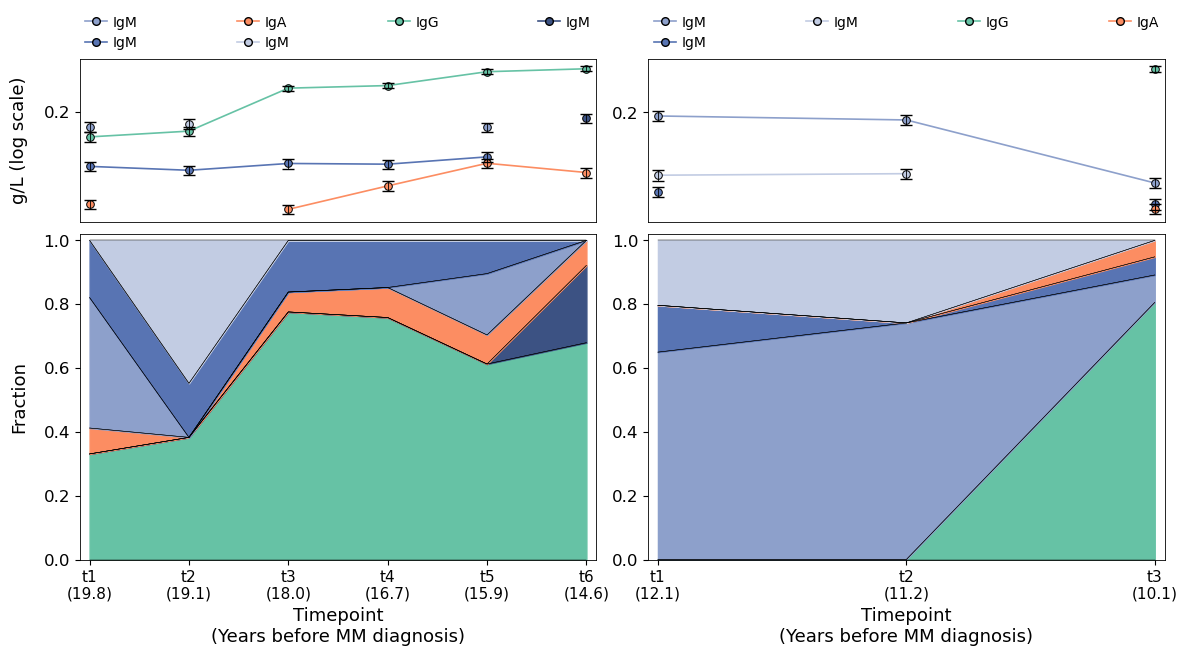

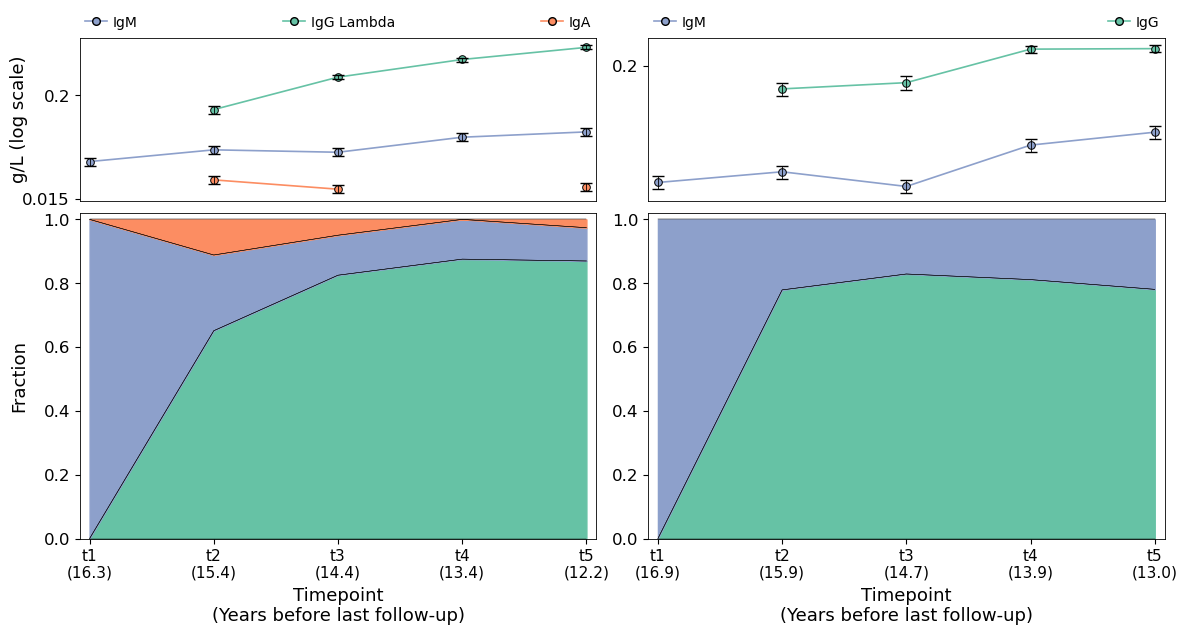

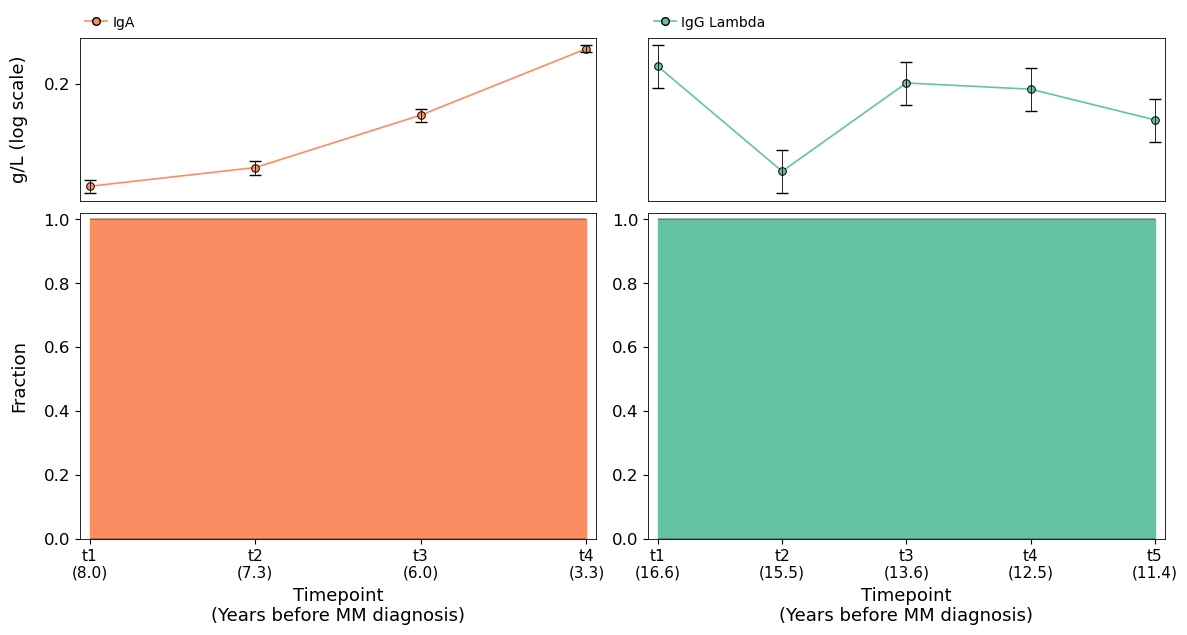

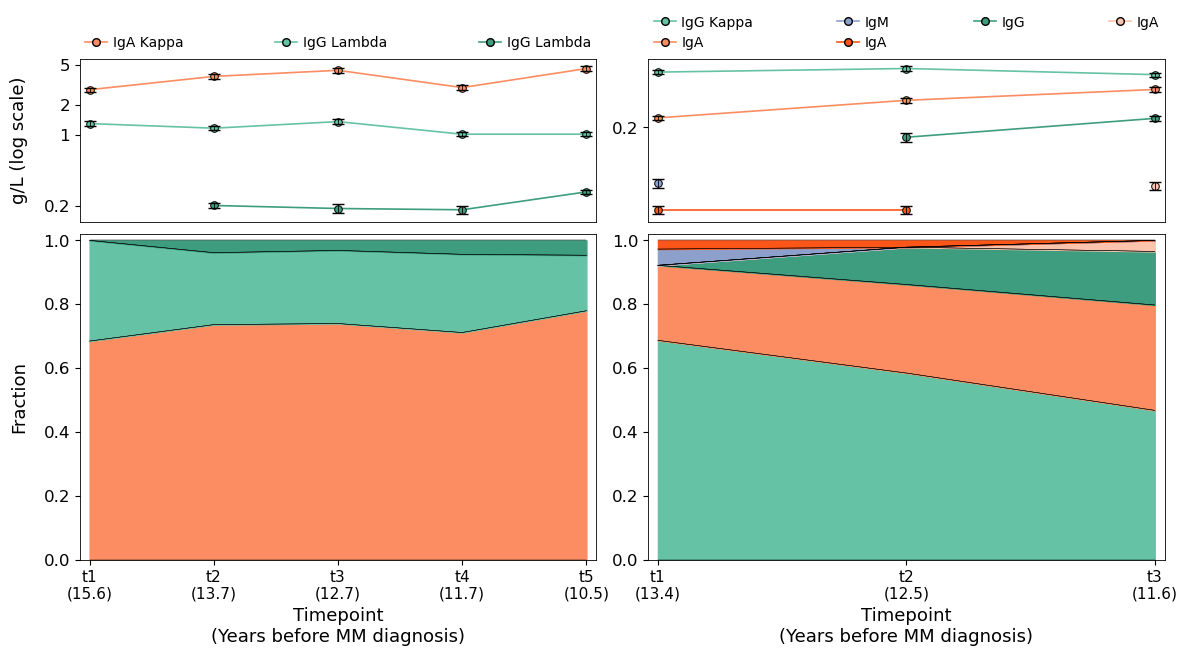

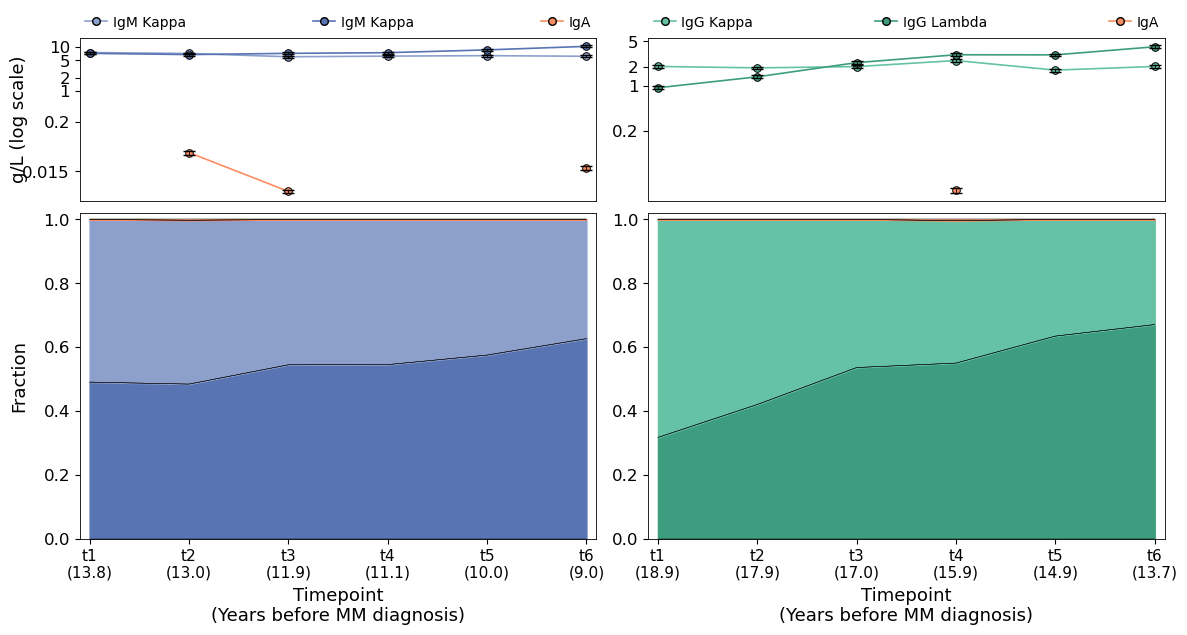

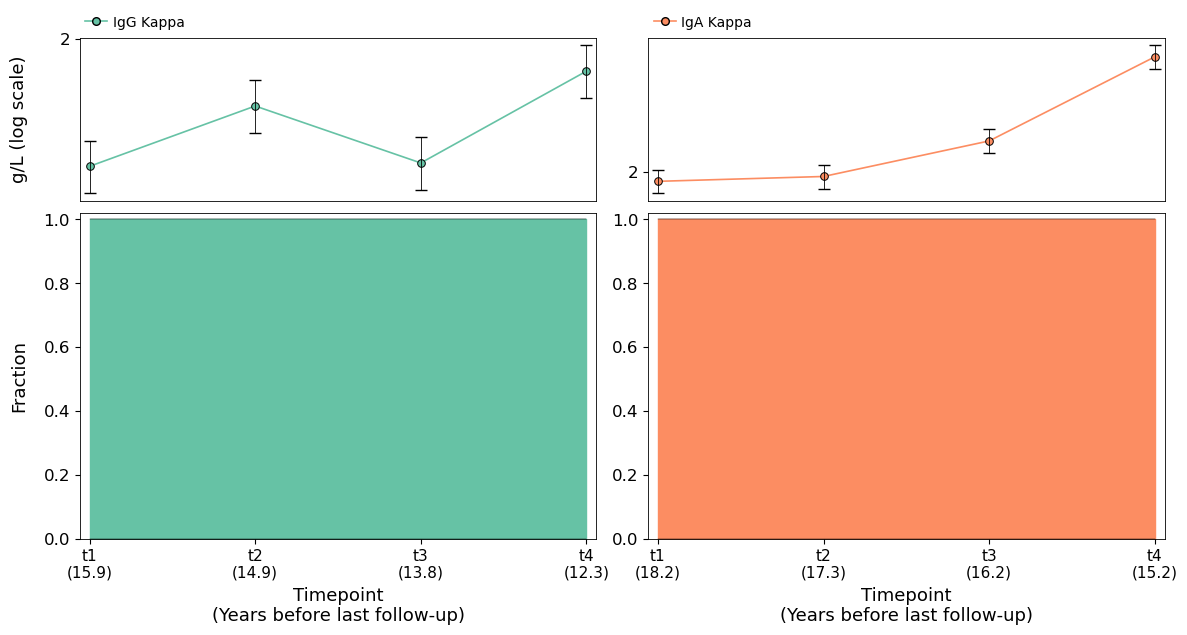

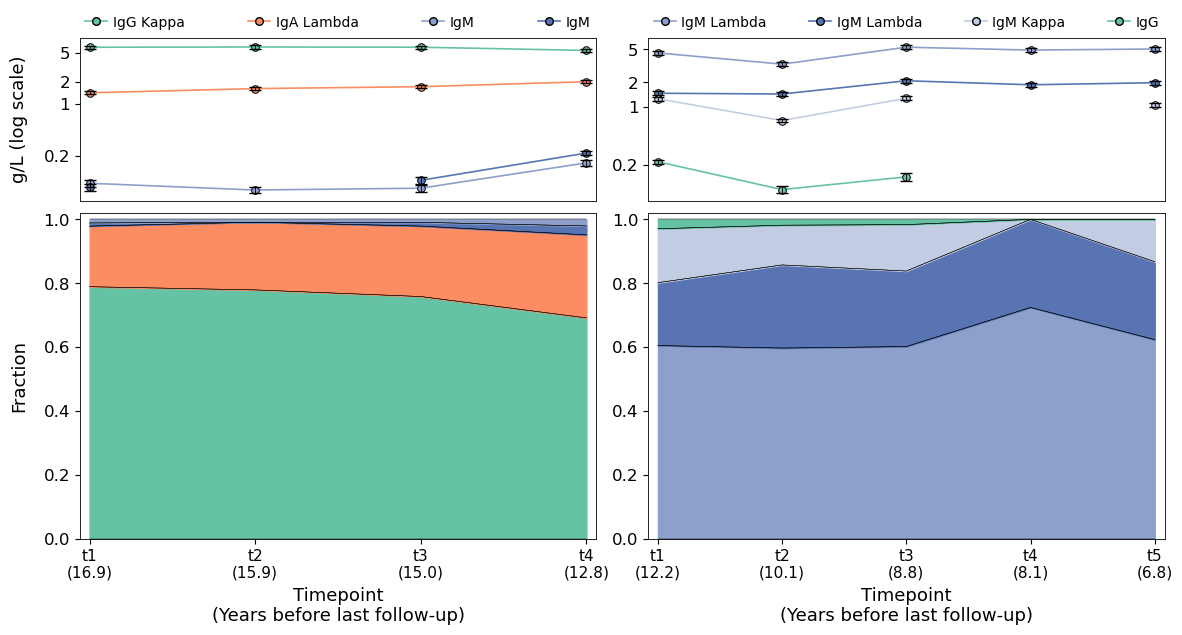

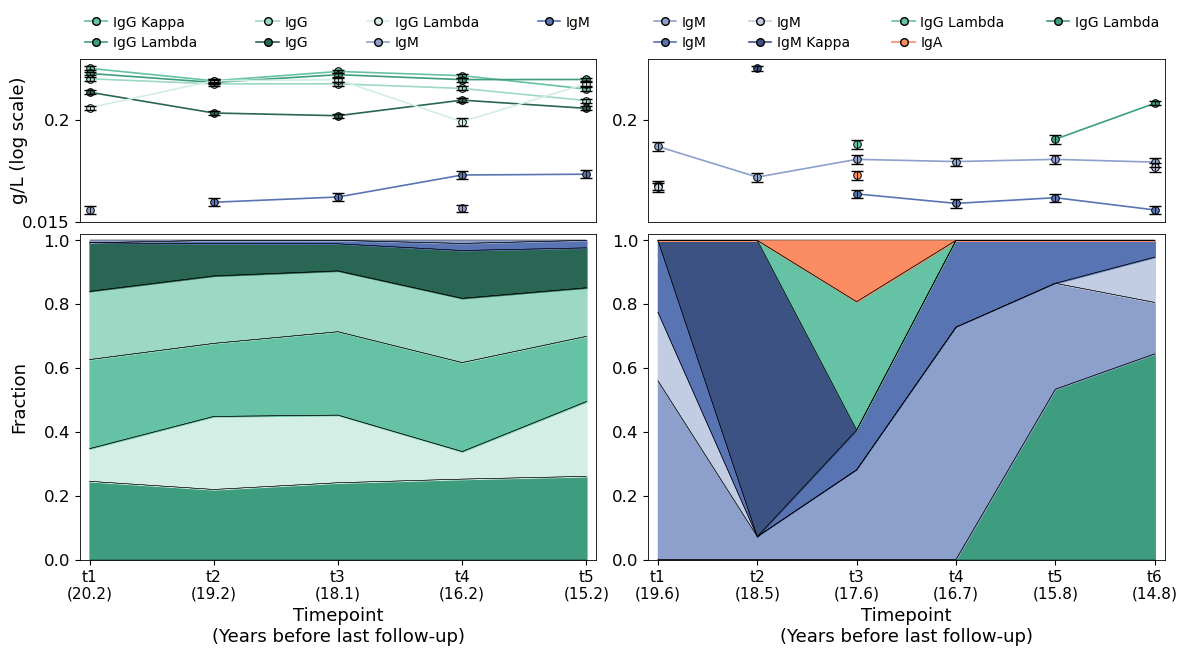

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb, to_hex
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter, NullLocator
import matplotlib.gridspec as gridspec
from collections import defaultdict
import colorsys
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# helper: palette
# -----------------------------
def generate_palette_from_base(base_color, n, delta=0.15):
    if n <= 1:
        return [base_color]

    base_rgb = to_rgb(base_color)
    h, l, s = colorsys.rgb_to_hls(*base_rgb)

    palette = [base_color]
    step = 1

    while len(palette) < n:
        if len(palette) < n:
            l_darker = max(0, l - delta * step)
            rgb = colorsys.hls_to_rgb(h, l_darker, s)
            palette.append(to_hex(rgb))

        if len(palette) < n:
            l_lighter = min(1, l + delta * step)
            rgb = colorsys.hls_to_rgb(h, l_lighter, s)
            palette.append(to_hex(rgb))

        step += 1

    return palette[:n]


# -----------------------------
# helper: clone label / color
# -----------------------------
def build_clone_color_maps(df):
    igh_colors = {
        'IgG': '#66c2a5',
        'IgA': '#fc8d62',
        'IgM': '#8da0cb',
    }

    clone_ids = sorted(df['Clone_ID'].dropna().unique())
    isotype_counts = defaultdict(int)
    clone_id_to_label = {}

    for clone_id in clone_ids:
        clone_data = df[df['Clone_ID'] == clone_id]
        unique_types = clone_data['Type_1'].dropna().unique()

        if len(unique_types) == 0:
            label = f"Unknown {clone_id}"
        else:
            label = " ".join(str(unique_types[0]).split("_"))

        clone_id_to_label[clone_id] = label
        iso = label.split()[0]
        isotype_counts[iso] += 1

    isotype_shades = {
        iso: generate_palette_from_base(base_color, isotype_counts[iso])
        for iso, base_color in igh_colors.items()
        if isotype_counts[iso] > 0
    }

    shade_indices = defaultdict(int)
    clone_id_to_color = {}

    for clone_id in clone_ids:
        label = clone_id_to_label[clone_id]
        iso = label.split()[0]

        if iso in isotype_shades:
            idx = shade_indices[iso]
            clone_id_to_color[clone_id] = isotype_shades[iso][idx]
            shade_indices[iso] += 1
        else:
            clone_id_to_color[clone_id] = "#999999"

    return clone_ids, clone_id_to_label, clone_id_to_color


# -----------------------------
# helper: one sample panel
# -----------------------------
def plot_one_sample(ax1, ax2, df_sample, sample_name, ticksize=12, innersize=13, titlesize=15):
    # remove non clones
    df_sample = df_sample[~df_sample['Clone_ID'].isna()].copy()
    df_sample = df_sample[~df_sample['Conc_1'].isna()].copy()

    if df_sample.empty:
        ax1.text(0.5, 0.5, f"{sample_name}\nNo valid clones",
                 ha="center", va="center", fontsize=titlesize)
        ax1.axis("off")
        ax2.axis("off")
        return

    df_sample["total_conc"] = df_sample.groupby(
        ["e_2021_1015_id", "timepoint"]
    )["Conc_1"].transform("sum")
    df_sample["conc_fraction"] = df_sample["Conc_1"] / df_sample["total_conc"]

    clone_ids, clone_id_to_label, clone_id_to_color = build_clone_color_maps(df_sample)

    # time order
    time_order_df = (
        df_sample[["timepoint", "Yr_before_dx"]]
        .drop_duplicates()
        .sort_values("timepoint")
        .reset_index(drop=True)
    )
    timepoints = time_order_df["timepoint"].tolist()
    x_positions = np.arange(len(timepoints))

    # -------- upper plot: concentration --------
    legend_handles = []
    legend_labels = []

    for clone_id in clone_ids:
        sub = (
            df_sample[df_sample["Clone_ID"] == clone_id]
            .groupby("timepoint", as_index=False)
            .agg({
                "Conc_1": "first",
                "Yr_before_dx": "first"
            })
            .set_index("timepoint")
            .reindex(timepoints)
            .reset_index()
        )

        y_vals = pd.to_numeric(sub["Conc_1"], errors="coerce").values.astype(float)

        y_plot = y_vals.copy()

        # <0 in log scale: small value
        valid_nonmissing = ~np.isnan(y_plot)
        y_plot[(valid_nonmissing) & (y_plot <= 0)] = 1e-4

        # 10% below 0.2g/L / 5% above 0.2g/L
        y_errs = np.full_like(y_plot, np.nan, dtype=float)
        present_mask = ~np.isnan(y_vals)
        y_errs[present_mask] = np.where(
            y_vals[present_mask] <= 0.2,
            y_vals[present_mask] * 0.10,
            y_vals[present_mask] * 0.05
        )

        color = clone_id_to_color[clone_id]
        label = clone_id_to_label[clone_id]

        ax1.plot(
            x_positions, y_plot,
            color=color,
            linestyle='-',
            linewidth=1.2,
            marker='o',
            markersize=5.5,
            markeredgewidth=0.7,
            markeredgecolor='black',
            zorder=2
        )

        # errorbar
        if present_mask.any():
            ax1.errorbar(
                x_positions[present_mask],
                y_plot[present_mask],
                yerr=y_errs[present_mask],
                fmt='none',
                ecolor='black',
                elinewidth=0.6,
                capsize=4,
                zorder=3
            )

        legend_handles.append(
            Line2D([0], [0],
                   color=color,
                   marker='o',
                   markerfacecolor=color,
                   markeredgecolor='black',
                   linewidth=1.2,
                   markersize=5.5)
        )
        legend_labels.append(label)

    ax1.set_xticks([])
    ax1.xaxis.set_visible(False)
    ax1.set_yscale('log')
    yticks = [0.015, 0.2, 1, 2, 5, 10]
    ax1.yaxis.set_major_locator(FixedLocator(yticks))
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))
    ax1.yaxis.set_minor_locator(NullLocator())
    ax1.yaxis.set_minor_formatter(NullFormatter())
    ax1.tick_params(axis='y', labelsize=ticksize)
    ax1.set_ylabel("g/L (log scale)", fontsize=innersize)

    n_legcol = min(len(legend_labels), 4)  

    ax1.legend(
        legend_handles,
        legend_labels,
        loc="lower left",
        bbox_to_anchor=(0, 1.02, 1, 0.2),   # ax1 right above
        mode="expand",                       
        ncol=n_legcol,
        fontsize=max(8, ticksize - 2),
        title=None,
        frameon=False,
        borderaxespad=0.0,
        handlelength=1.6,
        columnspacing=0.8,
        handletextpad=0.4
    )

    # -------- lower plot: stacked fraction --------
    stack_data = (
        df_sample.pivot_table(
            index="timepoint",
            columns="Clone_ID",
            values="conc_fraction",
            fill_value=0
        )
        .reindex(timepoints)
        .fillna(0)
    )

    if not stack_data.empty:
        ordered_cols = stack_data.iloc[-1].sort_values(ascending=False).index.tolist()
        stack_data = stack_data[ordered_cols]

        cum_data = stack_data.cumsum(axis=1)
        bottom_data = cum_data.shift(axis=1).fillna(0)

        for clone_id in stack_data.columns:
            color = clone_id_to_color[clone_id]

            ax2.fill_between(
                x_positions,
                bottom_data[clone_id].values,
                cum_data[clone_id].values,
                color=color
            )
            ax2.plot(
                x_positions,
                bottom_data[clone_id].values,
                color="black",
                linewidth=0.35,
                zorder=3
            )
            ax2.plot(
                x_positions,
                cum_data[clone_id].values,
                color="black",
                linewidth=0.35,
                zorder=3
            )

    xlabels = []
    yr_map = dict(zip(time_order_df["timepoint"], time_order_df["Yr_before_dx"]))
    for tp in timepoints:
        yr = yr_map.get(tp, np.nan)
        if pd.isna(yr):
            xlabels.append(f"{tp}")
        else:
            xlabels.append(f"{tp}\n({yr:.1f})")

    ax2.set_xticks(x_positions)
    ax2.set_xticklabels(xlabels, fontsize=ticksize - 1)
    ax2.set_ylim(0, 1.02)
    ax2.tick_params(axis='y', labelsize=ticksize)
    ax2.set_ylabel("Fraction", fontsize=innersize)
    
    disease_type = sample_name.split("-")[0]

    if disease_type == 'MM':
        ax2.set_xlabel("Timepoint\n(Years before MM diagnosis)", fontsize=innersize)
    elif disease_type == 'MGUS':
        ax2.set_xlabel("Timepoint\n(Years before last follow-up)", fontsize=innersize)
    
    ## y-axis label position
    label_x_pos = -0.1  

    for ax in [ax1, ax2]:
        ax.margins(x=0.02)
        
        ax.yaxis.set_label_coords(label_x_pos, 0.5)
        
        for side, spine in ax.spines.items():
            spine.set_visible(True)
            spine.set_edgecolor("black")
            spine.set_linewidth(0.6) 


# -----------------------------
# main plotting loop
# -----------------------------

ticksize = 17
outersize = 30
innersize = 24

########### Load data and execute the code ##########
filt_reshaped2 = pd.read_csv('../data/PLCO_ms_clone.csv', sep=",")

### remove 1) Type = Lambda or Kappa & Conc = 0.0, 2) C1q-1 (artifact), <LLMI, MSL --> Negative
remove_type = filt_reshaped2['Type_1'].isin(['Lambda', 'Kappa'])
remove_flag = filt_reshaped2['Flag_1'].isin(['C1q-1', 'MSL', '<LLMI'])

filt_reshaped2_filtered = filt_reshaped2.loc[~(remove_type | remove_flag)].copy()

### remove negative
mask_all_negative = (
    filt_reshaped2_filtered
    .groupby('e_2021_1015_id')['Mass_Spect_Diagnosis_SK']
    .transform(lambda x: (x == 'Negative').all())
)

filt_reshaped2_filtered = filt_reshaped2_filtered.loc[~mask_all_negative].copy()

sample_dict = {
    "MM basic": ['MM-035', 'MM-136'],
    "MM shifting": ['MM-106', 'MM-015'],
    "MM IgM to IgG": ['MM-061', 'MM-120'],
    "MGUS IgM to IgG": ['MGUS-237', 'MGUS-279'],
}

for key, sample_list in sample_dict.items():
    n_samples = len(sample_list)

    fig = plt.figure(figsize=(7 * n_samples, 6.5))
    outer = gridspec.GridSpec(1, n_samples, wspace=0.1)

    for i, sample in enumerate(sample_list):
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1,
            subplot_spec=outer[i],
            height_ratios=[1, 2],
            hspace=0.05
        )

        ax1 = fig.add_subplot(inner[0])
        ax2 = fig.add_subplot(inner[1], sharex=ax1)

        df_sample = filt_reshaped2_filtered[filt_reshaped2_filtered['e_2021_1015_id'] == sample].copy()
        plot_one_sample(ax1, ax2, df_sample, sample_name=sample)

        if i > 0:
            ax1.set_ylabel("")
            ax2.set_ylabel("")

    plt.tight_layout()
    plt.savefig(f"../00.Figures/Clonal_Dynamic_{key.replace(' ', '_')}.pdf", bbox_inches="tight")
    plt.show()

supple_dict = {
    "Supple MM monoclonal growth": ['MM-095', 'MM-092'],
    "Supple MM clonal dominance": ['MM-133', 'MM-023'],
    "Supple MM shifting dominance": ['MM-130', 'MM-021'],
    "Supple MGUS monoclonal growth": ['MGUS-066', 'MGUS-094'],
    "Supple MGUS clonal dominance": ['MGUS-104', 'MGUS-128'],
    "Supple MGUS shifting dominance and IgM to IgG": ['MGUS-103', 'MGUS-144'],
}
    
for key, sample_list in supple_dict.items():
    n_samples = len(sample_list)

    fig = plt.figure(figsize=(7 * n_samples, 6.5))
    outer = gridspec.GridSpec(1, n_samples, wspace=0.1)

    for i, sample in enumerate(sample_list):
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1,
            subplot_spec=outer[i],
            height_ratios=[1, 2],
            hspace=0.05
        )

        ax1 = fig.add_subplot(inner[0])
        ax2 = fig.add_subplot(inner[1], sharex=ax1)

        df_sample = filt_reshaped2_filtered[filt_reshaped2_filtered['e_2021_1015_id'] == sample].copy()
        plot_one_sample(ax1, ax2, df_sample, sample_name=sample)

        if i > 0:
            ax1.set_ylabel("")
            ax2.set_ylabel("")

    plt.tight_layout()
    plt.savefig(f"../00.Figures/Clonal_Dynamic_{key.replace(' ', '_')}.pdf", bbox_inches="tight")
    plt.show()
